# PPA 5 — Sistema Neurofuzzy ANFIS: exercícios resolvidos

**Autor:** João Pedro Machado Moura  
**Disciplina:** Inteligência Computacional — Engenharia da Computação  
**Base:** Aula 7 (`07_neurofuzzy_anfis_climatizacao.ipynb`)

Este notebook resolve os **8 exercícios** da seção 13 da aula e responde às
**perguntas propostas** (a previsão da seção 4 e os dois checkpoints). Cada exercício
tem código executável, resultados e uma análise escrita com base nesses resultados.

**Como o notebook está organizado**

1. *Preparação:* base simulada, modelo de referência da aula e um motor neurofuzzy geral
   (vários termos, operador E, ordem do consequente, poda).
2. *Perguntas da aula.*
3. *Exercícios 1 a 8.*
4. *Síntese.*

**Duas decisões que precisam ser declaradas**

- O Exercício 7 pede os dados do "Notebook 6" (robô), que **não está na pasta**. Simulei
  um conjunto equivalente (distâncias esquerda/frente/direita → velocidades das rodas)
  com um controlador de referência conhecido. Os números do Ex. 7 valem para essa
  simulação, não para os dados originais do Notebook 6.
- O Exercício 8 usa o conjunto real **AI4I 2020** (manutenção preditiva), que já estava em
  `../PPA 2/ai4i2020.csv`.

> Todas as sementes são fixas. O otimizador para em 100 iterações, sem convergir, como na
> aula; por isso os valores podem diferir na 3ª casa decimal dos que aparecem no
> notebook da aula, conforme a versão do SciPy/NumPy.

In [9]:
import copy
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import lsq_linear, minimize
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, f1_score, mean_absolute_error, mean_squared_error,
    precision_score, r2_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor

warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
CORES = ["#2A6FCE", "#F2B83F", "#D94B57", "#7655B7"]
pd.set_option("display.width", 140)
print("Ambiente carregado.")

Ambiente carregado.


## 0. Preparação

### 0.1 Base simulada da aula

Mesmo processo, mesma semente e mesma divisão treino–teste da aula. Uma única mudança
técnica: o ruído é guardado como ruído padrão `ruido_z` e multiplicado pelo desvio-padrão
(2,5 na aula). Assim o Exercício 1 pode variar o desvio-padrão **com a mesma realização
de ruído**, isolando o efeito da intensidade.

In [10]:
T_MIN, T_MAX = 16.0, 36.0
H_MIN, H_MAX = 20.0, 90.0

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def processo_sem_ruido(temperatura, umidade):
    efeito_temperatura = sigmoid((temperatura - 24.5) / 2.1)
    efeito_umidade = sigmoid((umidade - 60.0) / 10.0)
    interacao = sigmoid((temperatura - 27.0) / 1.6) * sigmoid((umidade - 55.0) / 9.0)
    potencia = 4 + 68 * efeito_temperatura + 10 * efeito_umidade + 18 * interacao
    return np.clip(potencia, 0, 100)

rng = np.random.default_rng(SEED)
n_amostras = 700
temperatura = rng.uniform(T_MIN, T_MAX, n_amostras)
umidade = rng.uniform(H_MIN, H_MAX, n_amostras)
ruido_z = rng.normal(0.0, 1.0, n_amostras)          # ruído padrão (desvio 1)
potencia_ideal = processo_sem_ruido(temperatura, umidade)
potencia_observada = np.clip(potencia_ideal + 2.5 * ruido_z, 0, 100)

def normalizar_entradas(temperatura, umidade):
    x_t = (np.asarray(temperatura) - T_MIN) / (T_MAX - T_MIN)
    x_h = (np.asarray(umidade) - H_MIN) / (H_MAX - H_MIN)
    return np.column_stack([x_t, x_h])

def desnormalizar_entradas(X):
    return T_MIN + X[:, 0] * (T_MAX - T_MIN), H_MIN + X[:, 1] * (H_MAX - H_MIN)

X = normalizar_entradas(temperatura, umidade)
idx_treino, idx_teste = train_test_split(
    np.arange(n_amostras), test_size=0.25, random_state=SEED
)
X_treino, X_teste = X[idx_treino], X[idx_teste]
y_treino, y_teste = potencia_observada[idx_treino], potencia_observada[idx_teste]
print(f"Treino: {len(X_treino)} amostras | Teste: {len(X_teste)} amostras")

Treino: 525 amostras | Teste: 175 amostras


### 0.2 Motor neurofuzzy geral

As funções da aula estavam fixas em 2 entradas × 3 termos, produto e consequente
constante. Os exercícios pedem variar exatamente essas escolhas, então generalizei o
mesmo algoritmo em uma classe `NeuroFuzzy`:

| Parâmetro | O que controla | Usado em |
|---|---|---|
| `termos=[m₁, m₂, …]` | nº de termos por entrada (regras = ∏mⱼ) | Ex. 2, 7, 8 |
| `operador="prod"/"min"` | operador E dos antecedentes | Ex. 3 |
| `ordem=0/1` | consequente constante ou linear | Ex. 5 |
| `centros_livres=True` | remove os limites dos centros | Ex. 6 |
| `ativas=` (máscara) | regras mantidas/podadas | Ex. 4 |

O algoritmo é o da aula: com as premissas fixas, os consequentes saem de mínimos
quadrados regularizados (limitados a [0, 100] na ordem zero); um L-BFGS-B ajusta centros
e log-larguras. Para 3 termos, os valores iniciais e limites são os da aula.

In [11]:
# ---- Motor neurofuzzy geral (generaliza as funções da aula) ----
import copy

def pertinencia_gaussiana(x, centros, sigmas):
    x = np.asarray(x)[:, None]
    return np.exp(-0.5 * ((x - centros[None, :]) / sigmas[None, :]) ** 2)

def cfg_termos(m):
    """Centros/larguras iniciais e limites admissíveis para m termos em [0, 1].
    Para m = 3 reproduz exatamente a configuração da aula."""
    if m == 3:
        return (np.array([0.12, 0.50, 0.88]), np.array([0.24, 0.22, 0.24]),
                [(0.00, 0.25), (0.35, 0.65), (0.75, 1.00)], [(0.08, 0.45)] * 3)
    c0 = np.linspace(0.12, 0.88, m)
    esp = c0[1] - c0[0]
    s0 = np.full(m, 0.63 * esp)
    meia = 0.45 * esp                      # < esp/2: a ordem dos termos é garantida
    lim_c = [(max(0.0, c - meia), min(1.0, c + meia)) for c in c0]
    lim_s = [(0.06, max(0.45, 1.3 * s0[0]))] * m
    return c0, s0, lim_c, lim_s

class NeuroFuzzy:
    def __init__(self, termos, operador="prod", ordem=0, lim_saida=(0.0, 100.0),
                 reg=1e-3, centros_livres=False, ativas=None):
        self.termos = list(termos)                 # nº de termos por entrada
        self.d = len(self.termos)
        self.operador = operador                   # "prod" ou "min"
        self.ordem = ordem                         # 0 ou 1 (Sugeno)
        self.lim_saida = lim_saida
        self.reg = reg
        self.centros_livres = centros_livres
        self.n_regras = int(np.prod(self.termos))
        self.ativas = (np.ones(self.n_regras, bool) if ativas is None
                       else np.asarray(ativas, bool))

    # ---------- premissas ----------
    def theta_inicial(self):
        cfg = [cfg_termos(m) for m in self.termos]
        return np.concatenate([c[0] for c in cfg] + [np.log(c[1]) for c in cfg])

    def limites(self):
        cfg = [cfg_termos(m) for m in self.termos]
        if self.centros_livres:
            lim_c = [(None, None)] * sum(self.termos)
        else:
            lim_c = [l for c in cfg for l in c[2]]
        lim_s = [(np.log(a), np.log(b)) for c in cfg for (a, b) in c[3]]
        return lim_c + lim_s

    def separar(self, theta):
        centros, sigmas, k = [], [], 0
        for m in self.termos:
            centros.append(theta[k:k + m]); k += m
        for m in self.termos:
            sigmas.append(np.exp(theta[k:k + m])); k += m
        return centros, sigmas

    def pesos(self, X, theta=None):
        theta = self.theta if theta is None else theta
        centros, sigmas = self.separar(theta)
        W = pertinencia_gaussiana(X[:, 0], centros[0], sigmas[0])
        for j in range(1, self.d):
            mu = pertinencia_gaussiana(X[:, j], centros[j], sigmas[j])
            if self.operador == "prod":
                W = (W[:, :, None] * mu[:, None, :]).reshape(len(X), -1)
            else:
                W = np.minimum(W[:, :, None], mu[:, None, :]).reshape(len(X), -1)
        W = W * self.ativas
        return W / (W.sum(axis=1, keepdims=True) + 1e-12)

    # ---------- consequentes ----------
    def _desenho(self, X, theta):
        Wn = self.pesos(X, theta)
        if self.ordem == 0:
            return Wn
        return np.hstack([Wn * X[:, [j]] for j in range(self.d)] + [Wn])

    def _coef(self, X, y2, theta):
        A = self._desenho(X, theta)
        n_col = A.shape[1]
        A_aug = np.vstack([A, np.sqrt(self.reg) * np.eye(n_col)])
        lim = self.lim_saida if self.ordem == 0 else (-np.inf, np.inf)
        cols = []
        for k in range(y2.shape[1]):
            b = np.concatenate([y2[:, k], np.zeros(n_col)])
            cols.append(lsq_linear(A_aug, b, bounds=lim, lsq_solver="exact").x)
        return np.column_stack(cols)

    def _prever(self, X, theta, coef):
        return np.clip(self._desenho(X, theta) @ coef, *self.lim_saida)

    # ---------- API ----------
    def fit(self, X, y, theta0=None, maxiter=100):
        y_arr = np.asarray(y, float)
        self._1d = y_arr.ndim == 1
        y2 = y_arr.reshape(len(y_arr), -1)
        theta0 = self.theta_inicial() if theta0 is None else np.asarray(theta0, float)

        def objetivo(theta):
            return np.mean((y2 - self._prever(X, theta, self._coef(X, y2, theta))) ** 2)

        self.theta0 = theta0
        self.historico = [objetivo(theta0)]
        self.res = minimize(
            objetivo, theta0, method="L-BFGS-B", bounds=self.limites(),
            callback=lambda th: self.historico.append(objetivo(th)),
            options={"maxiter": maxiter, "ftol": 1e-8, "maxls": 25},
        )
        self.theta = self.res.x
        self.coef = self._coef(X, y2, self.theta)
        return self

    def refit_consequentes(self, X, y):
        y_arr = np.asarray(y, float)
        self._1d = y_arr.ndim == 1
        self.coef = self._coef(X, y_arr.reshape(len(y_arr), -1), self.theta)
        return self

    def sem_treino(self, X, y):
        """Premissas iniciais (do especialista) + consequentes por mínimos quadrados."""
        self.theta = self.theta_inicial()
        return self.refit_consequentes(X, y)

    def predict(self, X):
        p = self._prever(X, self.theta, self.coef)
        return p[:, 0] if self._1d else p

    def ativacao_media(self, X):
        return self.pesos(X).mean(axis=0)

    @property
    def n_parametros(self):
        n_prem = 2 * sum(self.termos)
        n_cons = int(self.ativas.sum()) * (1 if self.ordem == 0 else self.d + 1)
        return n_prem + n_cons * self.coef.shape[1]

def calcular_metricas(y_real, y_pred):
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R²": r2_score(y_real, y_pred),
    }


### 0.3 Modelos de referência da aula (Sugeno de ordem 0, produto, 3×3 termos)

Serão a linha de base de quase todos os exercícios: o controlador manual, o neurofuzzy
aprendido e a MLP.

In [12]:
TERMOS_T = ["fria", "confortável", "quente"]
TERMOS_H = ["seca", "adequada", "úmida"]

consequentes_manuais = np.array([
    [5, 8, 12],
    [28, 40, 52],
    [70, 84, 96],
], dtype=float)

manual = NeuroFuzzy([3, 3])
manual.theta = manual.theta_inicial()
manual.coef = consequentes_manuais.reshape(-1, 1)
manual._1d = True

anfis = NeuroFuzzy([3, 3]).fit(X_treino, y_treino)

mlp = MLPRegressor(
    hidden_layer_sizes=(12,), activation="tanh", solver="lbfgs",
    alpha=1e-3, max_iter=1800, tol=1e-6, random_state=SEED,
).fit(X_treino, y_treino)

pred_manual = manual.predict(X_teste)
pred_anfis = anfis.predict(X_teste)
pred_mlp = np.clip(mlp.predict(X_teste), 0, 100)

metricas_base = pd.DataFrame({
    "Fuzzy manual": calcular_metricas(y_teste, pred_manual),
    "Neurofuzzy": calcular_metricas(y_teste, pred_anfis),
    "MLP": calcular_metricas(y_teste, pred_mlp),
}).T
print(f"MSE de treino do neurofuzzy: {anfis.historico[0]:.3f} → {anfis.historico[-1]:.3f} "
      f"({anfis.res.nit} iterações)")
metricas_base.round(4)

MSE de treino do neurofuzzy: 25.267 → 6.077 (100 iterações)


,MAE,RMSE,R²
Fuzzy manual,10.3715,12.2628,0.8171
Neurofuzzy,2.1784,2.7256,0.9910
MLP,2.2754,2.8770,0.9899


In [13]:
# Auxiliares de visualização usados nos exercícios
grade = np.linspace(0, 1, 300)
LIMITES_FISICOS = [(T_MIN, T_MAX), (H_MIN, H_MAX)]

def plotar_pertinencias(ax, modelo, j, termos, titulo, mostrar_inicial=True):
    minimo, maximo = LIMITES_FISICOS[j]
    x_fis = minimo + grade * (maximo - minimo)
    c, s = modelo.separar(modelo.theta)
    c0, s0 = modelo.separar(modelo.theta_inicial())
    for i, nome in enumerate(termos):
        cor = CORES[i % len(CORES)]
        if mostrar_inicial:
            ax.plot(x_fis, pertinencia_gaussiana(grade, c0[j], s0[j])[:, i],
                    "--", lw=1.3, color=cor, alpha=0.55)
        ax.plot(x_fis, pertinencia_gaussiana(grade, c[j], s[j])[:, i],
                lw=2.3, color=cor, label=nome)
    ax.set(title=titulo, ylim=(-0.02, 1.05),
           xlabel="°C" if j == 0 else "% UR")
    ax.legend(fontsize=8)

t_grid = np.linspace(T_MIN, T_MAX, 100)
h_grid = np.linspace(H_MIN, H_MAX, 100)
TT, HH = np.meshgrid(t_grid, h_grid)
X_grade = normalizar_entradas(TT.ravel(), HH.ravel())

def superficie(modelo):
    return modelo.predict(X_grade).reshape(TT.shape)

def centros_fisicos(modelo):
    c, s = modelo.separar(modelo.theta)
    return [
        (LIMITES_FISICOS[j][0] + c[j] * (LIMITES_FISICOS[j][1] - LIMITES_FISICOS[j][0]),
         s[j] * (LIMITES_FISICOS[j][1] - LIMITES_FISICOS[j][0]))
        for j in range(2)
    ]

(c_t, s_t), (c_h, s_h) = centros_fisicos(anfis)
print("Centros aprendidos — temperatura (°C):", c_t.round(1), "| umidade (%):", c_h.round(1))
print("Larguras σ — temperatura (°C):", s_t.round(1), "| umidade (%):", s_h.round(1))

Centros aprendidos — temperatura (°C): [21.  28.5 31.8] | umidade (%): [31.8 44.9 72.5]
Larguras σ — temperatura (°C): [4.8 3.8 2.2] | umidade (%): [ 8.4 13.4 23. ]


## 1. Perguntas propostas na aula

### 1.1 Previsão (seção 4)

> *Em qual região do plano temperatura–umidade o modelo deverá produzir a maior
> potência? A umidade deveria ter o mesmo efeito em todas as temperaturas?*

Em vez de responder só pela intuição, verifico no processo gerador (sem ruído) e no
modelo aprendido.

Máximo (processo sem ruído): 98.8% em T=36.0 °C, UR=90.0%
Máximo (neurofuzzy): 97.9% em T=35.4 °C, UR=90.0%


,T (°C),real UR=30%,real UR=80%,Δ real (80−30),Δ neurofuzzy (80−30)
0,18.0,7.4,15.8,8.4,7.9
1,22.0,20.4,29.4,9.0,9.7
2,25.0,42.7,54.6,11.9,13.0
3,27.0,57.1,73.4,16.3,16.0
4,30.0,68.8,90.9,22.1,22.1
5,34.0,72.8,96.8,24.0,25.4


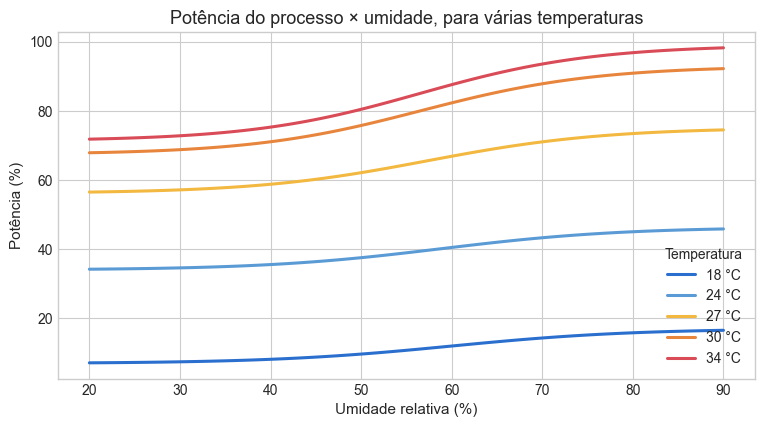

In [14]:
# (a) onde está a potência máxima? (processo verdadeiro e modelo aprendido)
Z_real = processo_sem_ruido(TT, HH)
Z_anfis = superficie(anfis)
for nome, Z in [("processo sem ruído", Z_real), ("neurofuzzy", Z_anfis)]:
    i, j = np.unravel_index(np.argmax(Z), Z.shape)
    print(f"Máximo ({nome}): {Z[i, j]:.1f}% em T={TT[i, j]:.1f} °C, UR={HH[i, j]:.1f}%")

# (b) efeito da umidade (UR 30% → 80%) em cada temperatura
temps = np.array([18, 22, 25, 27, 30, 34], dtype=float)
def prever_pontos(modelo, t, u):
    return modelo.predict(normalizar_entradas(t, u))

efeito = pd.DataFrame({
    "T (°C)": temps,
    "real UR=30%": processo_sem_ruido(temps, 30.0),
    "real UR=80%": processo_sem_ruido(temps, 80.0),
    "Δ real (80−30)": processo_sem_ruido(temps, 80.0) - processo_sem_ruido(temps, 30.0),
    "Δ neurofuzzy (80−30)": prever_pontos(anfis, temps, np.full_like(temps, 80.0))
                            - prever_pontos(anfis, temps, np.full_like(temps, 30.0)),
}).round(1)
display(efeito)

fig, ax = plt.subplots(figsize=(9, 4.5))
for t_i, cor in zip([18, 24, 27, 30, 34], ["#2A6FCE", "#5B9BD5", "#F2B83F", "#E8853D", "#D94B57"]):
    ax.plot(h_grid, processo_sem_ruido(float(t_i), h_grid), lw=2.2, color=cor, label=f"{t_i} °C")
ax.set(title="Potência do processo × umidade, para várias temperaturas",
       xlabel="Umidade relativa (%)", ylabel="Potência (%)")
ax.legend(title="Temperatura")
plt.show()

**Resposta.**

- **Onde a potência é máxima:** no canto **quente e úmido**. No processo verdadeiro o máximo é
  98,8% em 36 °C e 90% UR; o neurofuzzy aprendeu 97,9% em 35,4 °C e 90% UR.
- **A umidade tem o mesmo efeito em todas as temperaturas? Não.** Passar de 30% para 80% de UR
  soma cerca de **8 pontos a 18 °C, 16 pontos a 27 °C e 24 pontos a 34 °C** no processo real.
  O neurofuzzy reproduz essa progressão (7,9 → 16,0 → 25,4).

**Por quê.** O processo tem um termo aditivo da umidade (até 10 pontos) e um termo de
**interação** (18 × σ(T) × σ(UR)) que só "liga" acima de ≈ 27 °C. No frio a umidade quase não
importa; no calor ela decide os últimos 20 pontos. Por isso o modelo precisa de regras que
combinem as duas entradas (as 9 regras do produto cartesiano fazem isso), e não de duas
regras independentes, uma por variável.

### 1.2 Checkpoint 1 — o sistema manual é um modelo neurofuzzy?

In [15]:
# Evidência: o manual não tem nenhum parâmetro aprendido; o erro é bem maior.
print("Parâmetros ajustados aos dados (manual):", 0)
print(f"RMSE teste — manual: {metricas_base.loc['Fuzzy manual', 'RMSE']:.2f} | "
      f"neurofuzzy: {metricas_base.loc['Neurofuzzy', 'RMSE']:.2f}")
print(f"Parâmetros do neurofuzzy ajustados aos dados: {anfis.n_parametros} "
      f"(12 de premissas + 9 consequentes)")

Parâmetros ajustados aos dados (manual): 0
RMSE teste — manual: 12.26 | neurofuzzy: 2.73
Parâmetros do neurofuzzy ajustados aos dados: 21 (12 de premissas + 9 consequentes)


**Resposta: ainda não.** O controlador manual tem a *estrutura* de um Sugeno (gaussianas,
9 regras, média ponderada), mas nenhum dos seus 21 números (12 de premissas e 9 consequentes)
foi ajustado a dados. É uma hipótese do especialista, e uma hipótese ruim: RMSE de 12,26 no teste,
contra 2,73 do neurofuzzy (R² de 0,82 contra 0,99).

Neurofuzzy é a **mesma estrutura com parâmetros estimados dos dados**. Os dados corrigiram
sobretudo a linha "confortável": o consequente foi de 28 / 40 / 52% para ≈ 79 / 77 / 100%, e o
centro de "confortável" foi de 26 °C para 28,5 °C. O especialista subestimou a potência já na faixa
de 27–29 °C.

### 1.3 Checkpoint 2 — onde está a parte "neural"?

In [16]:
camadas = pd.DataFrame({
    "Camada": [1, 2, 3, 4, 5],
    "Operação": ["Fuzzificação (gaussianas)", "Ativação da regra (produto)",
                 "Normalização", "Consequente", "Agregação (soma)"],
    "Fórmula": ["μᵢⱼ(xⱼ)", "wᵢ = ∏ⱼ μᵢⱼ", "w̄ᵢ = wᵢ / Σₖwₖ", "w̄ᵢ · zᵢ", "ŷ = Σᵢ w̄ᵢ zᵢ"],
    "Parâmetros aprendidos": ["centros e larguras (12)", "nenhum", "nenhum",
                              "zᵢ (9)", "nenhum"],
})
camadas

,Camada,Operação,Fórmula,Parâmetros aprendidos
0,1,Fuzzificação (gaussianas),μᵢⱼ(xⱼ),centros e larguras (12)
1,2,Ativação da regra (produto),wᵢ = ∏ⱼ μᵢⱼ,nenhum
2,3,Normalização,w̄ᵢ = wᵢ / Σₖwₖ,nenhum
3,4,Consequente,w̄ᵢ · zᵢ,zᵢ (9)
4,5,Agregação (soma),ŷ = Σᵢ w̄ᵢ zᵢ,nenhum


**Resposta.** O "neural" está na **arquitetura em camadas, diferenciável e treinada por
otimização**, não em neurônios densos. As cinco camadas da tabela acima fazem o papel das camadas
de uma rede; só as camadas 1 e 4 têm parâmetros (12 + 9 = 21, o equivalente aos "pesos"), e são eles
que o aprendizado ajusta: as premissas por otimização quasi-Newton (L-BFGS-B) e os consequentes por
mínimos quadrados, que é o aprendizado híbrido.

A diferença para uma MLP é que aqui **cada parâmetro tem significado físico** (um centro em °C, uma
potência em %), então é possível auditar o que foi aprendido.

---
## Exercício 1 — Ruído

> *Repita o experimento com desvios-padrão 1, 5 e 10. Compare erro e deslocamento das
> pertinências.*

Mantenho as mesmas entradas, a mesma divisão e a mesma realização de ruído
(`ruido_z`), variando só o desvio-padrão. Incluo 2,5 (valor da aula) como referência.
Além do erro contra a saída ruidosa observada, calculo o erro contra o **processo sem
ruído** no conjunto de teste, que mede quão bem o modelo aprendeu a função verdadeira.

In [17]:
NIVEIS_RUIDO = [1.0, 2.5, 5.0, 10.0]
ideal_teste = potencia_ideal[idx_teste]

modelos_ruido, linhas = {}, []
for sd in NIVEIS_RUIDO:
    y_sd = np.clip(potencia_ideal + sd * ruido_z, 0, 100)
    mod = NeuroFuzzy([3, 3]).fit(X_treino, y_sd[idx_treino])
    modelos_ruido[sd] = mod
    p = mod.predict(X_teste)
    c0, s0 = mod.separar(mod.theta0)
    desloc_c = np.mean(np.abs(np.concatenate([mod.separar(mod.theta)[0][j] - c0[j] for j in range(2)])))
    desloc_s = np.mean(np.abs(np.concatenate([mod.separar(mod.theta)[1][j] - s0[j] for j in range(2)])))
    linhas.append({
        "desvio σ do ruído": sd,
        "RMSE teste (vs. observado)": np.sqrt(mean_squared_error(y_sd[idx_teste], p)),
        "RMSE teste (vs. processo real)": np.sqrt(mean_squared_error(ideal_teste, p)),
        "R² (vs. observado)": r2_score(y_sd[idx_teste], p),
        "desloc. médio dos centros": desloc_c,
        "desloc. médio das larguras": desloc_s,
        "MSE treino final": mod.historico[-1],
    })
tabela_ruido = pd.DataFrame(linhas).set_index("desvio σ do ruído")
display(tabela_ruido.round(3))

partes = []
for sd, mod in modelos_ruido.items():
    (ct, st), (ch, sh) = centros_fisicos(mod)
    partes.append(pd.Series(
        list(ct.round(1)) + list(ch.round(1)),
        index=[f"c_T {n}" for n in TERMOS_T] + [f"c_UR {n}" for n in TERMOS_H], name=sd))
print("Centros aprendidos (T em °C, UR em %). Iniciais: T = 18.4 / 26.0 / 33.6 °C; UR = 28.4 / 55.0 / 81.6 %")
display(pd.DataFrame(partes))

,RMSE teste (vs. observado),RMSE teste (vs. processo real),R² (vs. observado),desloc. médio dos centros,desloc. médio das larguras,MSE treino final
desvio σ do ruído,,,,,,
1.0,1.133,0.322,0.998,0.113,0.054,1.043
2.5,2.726,0.461,0.991,0.111,0.066,6.077
5.0,5.320,0.776,0.967,0.123,0.065,23.017
10.0,10.267,1.824,0.884,0.128,0.063,84.399


Centros aprendidos (T em °C, UR em %). Iniciais: T = 18.4 / 26.0 / 33.6 °C; UR = 28.4 / 55.0 / 81.6 %


,c_T fria,c_T confortável,c_T quente,c_UR seca,c_UR adequada,c_UR úmida
1.0,20.9,29.0,31.8,37.4,49.5,74.2
2.5,21.0,28.5,31.8,31.8,44.9,72.5
5.0,21.0,28.3,31.5,21.1,44.5,72.5
10.0,20.4,29.0,36.0,20.0,44.5,72.5


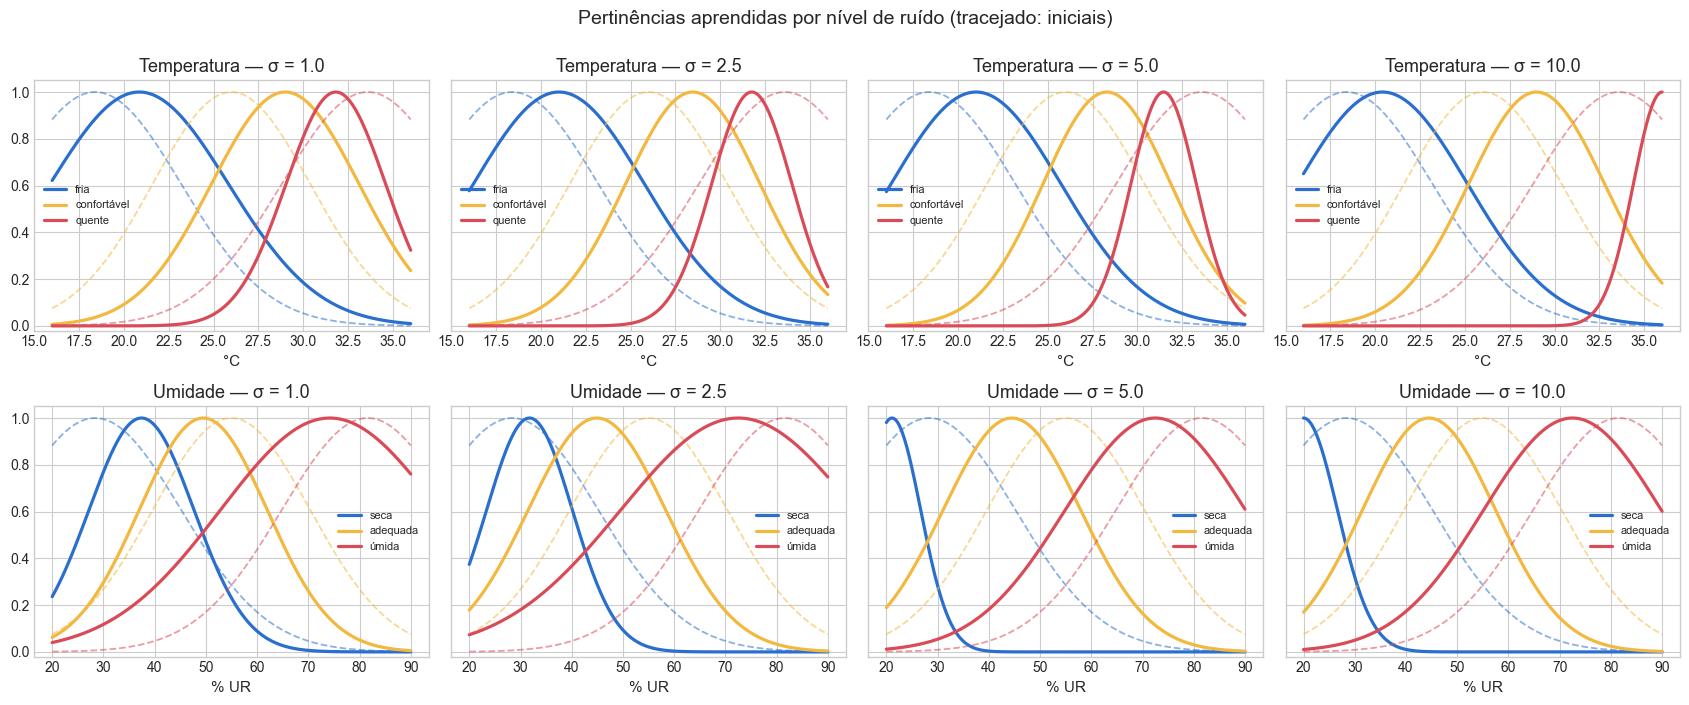

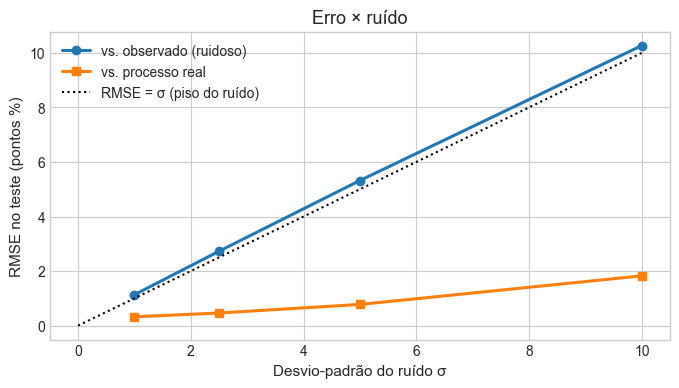

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7), sharey=True)
for col, sd in enumerate(NIVEIS_RUIDO):
    plotar_pertinencias(axes[0, col], modelos_ruido[sd], 0, TERMOS_T, f"Temperatura — σ = {sd}")
    plotar_pertinencias(axes[1, col], modelos_ruido[sd], 1, TERMOS_H, f"Umidade — σ = {sd}")
fig.suptitle("Pertinências aprendidas por nível de ruído (tracejado: iniciais)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tabela_ruido.index, tabela_ruido["RMSE teste (vs. observado)"], "o-", lw=2.2, label="vs. observado (ruidoso)")
ax.plot(tabela_ruido.index, tabela_ruido["RMSE teste (vs. processo real)"], "s-", lw=2.2, label="vs. processo real")
ax.plot([0, 10], [0, 10], "k:", label="RMSE = σ (piso do ruído)")
ax.set(xlabel="Desvio-padrão do ruído σ", ylabel="RMSE no teste (pontos %)", title="Erro × ruído")
ax.legend()
plt.show()

In [19]:
# Robustez: as conclusões acima vêm de UMA realização de ruído. Repito com 5 realizações diferentes.
N_REP = 5
linhas = []
for sd in NIVEIS_RUIDO:
    for rep in range(N_REP):
        z_r = np.random.default_rng(1000 + rep).normal(0.0, 1.0, n_amostras)
        y_r = np.clip(potencia_ideal + sd * z_r, 0, 100)
        mod = NeuroFuzzy([3, 3]).fit(X_treino, y_r[idx_treino])
        (ct, st), (ch, sh) = centros_fisicos(mod)
        p = mod.predict(X_teste)
        linhas.append({"σ": sd,
                       **{f"T {n}": v for n, v in zip(TERMOS_T, ct)},
                       **{f"UR {n}": v for n, v in zip(TERMOS_H, ch)},
                       "RMSE vs. processo real": np.sqrt(mean_squared_error(ideal_teste, p))})
rob = pd.DataFrame(linhas).groupby("σ")
print(f"Média dos centros aprendidos em {N_REP} realizações de ruído (T em °C, UR em %):")
display(rob.mean().round(2))
print("Desvio-padrão entre as realizações (quanto o resultado depende do sorteio do ruído):")
display(rob.std().round(2))

Média dos centros aprendidos em 5 realizações de ruído (T em °C, UR em %):


,T fria,T confortável,T quente,UR seca,UR adequada,UR úmida,RMSE vs. processo real
σ,,,,,,,
1.0,21.00,29.0,31.78,37.00,47.75,84.89,0.34
2.5,20.96,29.0,31.50,37.50,49.82,82.39,0.49
5.0,20.99,28.6,32.36,35.53,51.60,80.32,0.91
10.0,20.74,28.8,33.80,35.35,50.33,80.15,1.88


Desvio-padrão entre as realizações (quanto o resultado depende do sorteio do ruído):


,T fria,T confortável,T quente,UR seca,UR adequada,UR úmida,RMSE vs. processo real
σ,,,,,,,
1.0,0.01,0.00,0.43,1.11,0.94,7.76,0.03
2.5,0.07,0.01,0.19,0.00,3.27,6.93,0.05
5.0,0.03,0.48,1.81,2.83,7.00,6.59,0.16
10.0,0.42,0.30,1.76,2.34,5.40,7.97,0.42


**Análise.**

*Erro.* O RMSE contra a saída observada acompanha o ruído e fica logo acima dele
(1,13 / 2,73 / 5,32 / 10,27 para σ = 1 / 2,5 / 5 / 10). O ruído é o piso do erro: nenhum modelo o
prevê. Já o erro contra o **processo real** é muito menor que σ (0,32 / 0,46 / 0,78 / 1,82): o
modelo continua recuperando a função verdadeira, mas piora ≈ 5,7 vezes de σ = 1 para σ = 10. O R²
cai de 0,998 para 0,884 só porque a variância explicável fica pequena diante do ruído.

*Deslocamento das pertinências.* Na realização principal, o deslocamento médio dos centros em
relação à hipótese do especialista é quase o mesmo em todos os níveis (0,11 a 0,13 em unidades
normalizadas). **A maior parte do deslocamento vem do formato dos dados, não do ruído**: mesmo com
σ = 1, "fria" foi de 18,4 para 21,0 °C e "confortável" de 26 para 29 °C. As médias de 5 realizações
mostram que esses dois centros ficam nos mesmos valores (21,0 e 29,0 °C, nos limites permitidos) e
com desvio praticamente nulo em σ baixo.

*O que o ruído realmente muda: a reprodutibilidade.* O desvio-padrão entre realizações cresce
para os centros mal determinados, por exemplo "UR adequada" (0,9 → 3,3 → 7,0 → 5,4 pontos) e
"T quente" (0,4 → 0,2 → 1,8 → 1,8 °C), e o centro médio de "T quente" sobe de 31,8 para 33,8 °C.
"UR úmida" é instável (desvio de 6,6 a 8,0 pontos em todos os níveis) mesmo com pouco ruído. Na figura, as pertinências
de σ = 5 e σ = 10 chegam a degenerar em picos estreitos colados nas bordas ("seca" em 20% UR,
"quente" em 36 °C). Esse colapso ocorreu **nesta realização**; nas 5 realizações adicionais o centro de "seca"
fica entre 35 e 37,5% UR, com desvio de até 3 pontos. Ele ilustra a instabilidade, não um
deslocamento sistemático.

*Conclusão.* Ruído alto não destrói o erro contra o processo real, mas torna as **fronteiras
linguísticas pouco reprodutíveis**, sobretudo para a umidade, que tem efeito pequeno (10 a 25
pontos) diante do ruído. Antes de interpretar centros e larguras, vale checar a estabilidade com
mais de uma realização (ou reamostragem).

---
## Exercício 2 — Complexidade

> *Use dois, três e quatro termos por entrada. Compare quantidade de regras,
> desempenho e interpretabilidade.*

,regras,parâmetros,RMSE treino,RMSE teste,R² teste,RMSE vs. processo real,tempo (s),consequentes fora de ordem
termos/entrada,,,,,,,,
2,4,12,2.571,2.811,0.990,0.724,0.512,0 de 4 pares
3,9,21,2.465,2.726,0.991,0.461,2.170,3 de 12 pares
4,16,32,2.401,2.769,0.991,0.617,3.371,4 de 24 pares


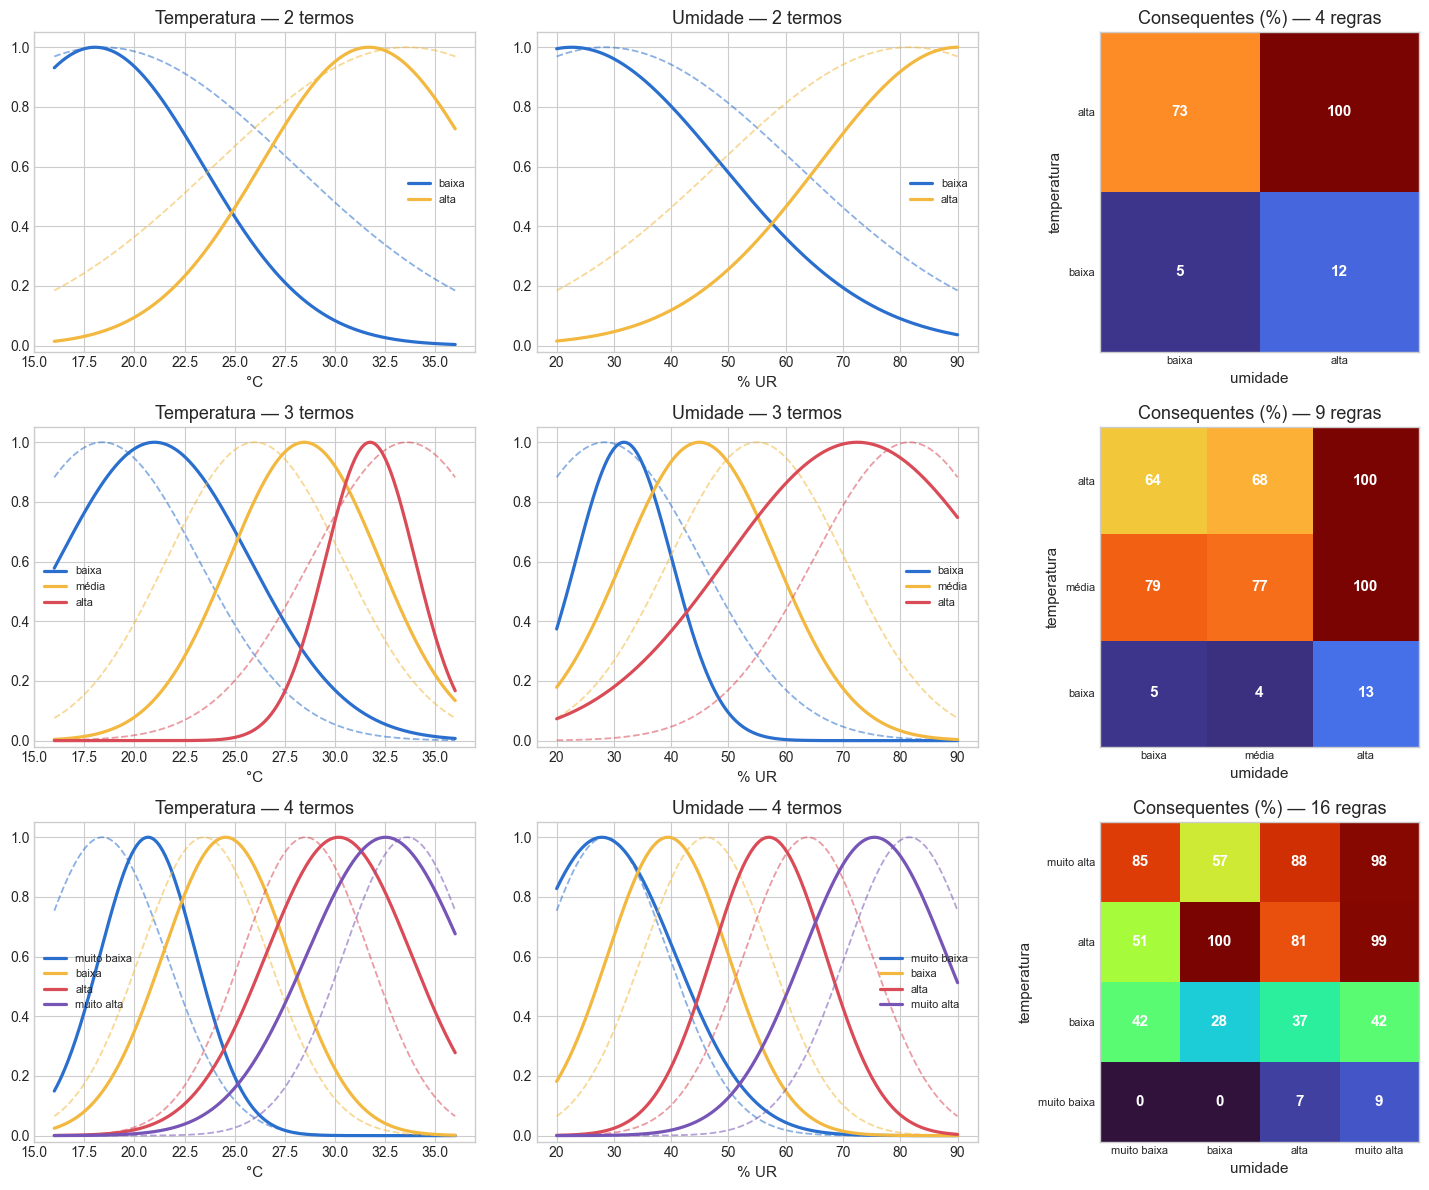

Nº de regras de uma grade completa (m^d):


,2 entradas,3 entradas,6 entradas
termos/entrada,,,
2,4,8,64
3,9,27,729
4,16,64,4096
5,25,125,15625


In [20]:
NOMES_TERMOS = {
    2: ["baixa", "alta"],
    3: ["baixa", "média", "alta"],
    4: ["muito baixa", "baixa", "alta", "muito alta"],
}
def inversoes(cons, tol=1.0):
    # pares vizinhos em que a potência CAI quando a temperatura ou a umidade AUMENTA
    # (o processo real é crescente nas duas entradas)
    d_t, d_h = np.diff(cons, axis=0), np.diff(cons, axis=1)
    return int((d_t < -tol).sum() + (d_h < -tol).sum()), d_t.size + d_h.size

modelos_m, linhas = {}, []
for m in [2, 3, 4]:
    t0 = time.time()
    mod = NeuroFuzzy([m, m]).fit(X_treino, y_treino)
    modelos_m[m] = mod
    linhas.append({
        "termos/entrada": m,
        "regras": mod.n_regras,
        "parâmetros": mod.n_parametros,
        "RMSE treino": np.sqrt(mean_squared_error(y_treino, mod.predict(X_treino))),
        "RMSE teste": np.sqrt(mean_squared_error(y_teste, mod.predict(X_teste))),
        "R² teste": r2_score(y_teste, mod.predict(X_teste)),
        "RMSE vs. processo real": np.sqrt(mean_squared_error(ideal_teste, mod.predict(X_teste))),
        "tempo (s)": time.time() - t0,
    })
    n_inv, n_par_viz = inversoes(mod.coef[:, 0].reshape(m, m))
    linhas[-1]["consequentes fora de ordem"] = f"{n_inv} de {n_par_viz} pares"
tabela_m = pd.DataFrame(linhas).set_index("termos/entrada")
display(tabela_m.round(3))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for r, m in enumerate([2, 3, 4]):
    mod = modelos_m[m]
    plotar_pertinencias(axes[r, 0], mod, 0, NOMES_TERMOS[m], f"Temperatura — {m} termos")
    plotar_pertinencias(axes[r, 1], mod, 1, NOMES_TERMOS[m], f"Umidade — {m} termos")
    cons = mod.coef[:, 0].reshape(m, m)
    ax = axes[r, 2]
    im = ax.imshow(cons, origin="lower", cmap="turbo", vmin=0, vmax=100)
    for i in range(m):
        for j in range(m):
            ax.text(j, i, f"{cons[i, j]:.0f}", ha="center", va="center", color="white",
                    fontsize=11, fontweight="bold")
    ax.set(xticks=range(m), yticks=range(m), title=f"Consequentes (%) — {m*m} regras",
           xlabel="umidade", ylabel="temperatura")
    ax.set_xticklabels(NOMES_TERMOS[m], fontsize=8); ax.set_yticklabels(NOMES_TERMOS[m], fontsize=8)
    ax.grid(False)
plt.tight_layout()
plt.show()

crescimento = pd.DataFrame(
    {f"{d} entradas": [m ** d for m in [2, 3, 4, 5]] for d in [2, 3, 6]},
    index=pd.Index([2, 3, 4, 5], name="termos/entrada"),
)
print("Nº de regras de uma grade completa (m^d):")
crescimento

**Análise.**

| termos | regras | parâmetros | RMSE treino | RMSE teste | RMSE vs. processo real | consequentes fora de ordem |
|---|---|---|---|---|---|---|
| 2 | 4 | 12 | 2,571 | 2,811 | 0,724 | 0 de 4 |
| 3 | 9 | 21 | 2,465 | **2,726** | **0,461** | 3 de 12 |
| 4 | 16 | 32 | 2,401 | 2,769 | 0,617 | 4 de 24 |

*Desempenho.* A curva tem forma de U. Com **2 termos** o modelo é grosseiro demais para a
transição em S e para a interação (erro vs. real 0,72). Com **3 termos** obtém-se o melhor teste e o
melhor erro contra o processo real. Com **4 termos** o erro de treino (2,40) já fica abaixo do ruído
(σ = 2,5), sinal de que o modelo começa a ajustar ruído, e o teste piora (2,77). As diferenças no RMSE
de teste são pequenas (≈ 3%) porque todos estão perto do piso do ruído; a coluna "vs. processo
real" é o indicador mais sensível.

*Regras.* Crescem como m²: 4 → 9 → 16. Com d entradas seriam m^d (tabela acima): 3 termos e 6
sensores dão 729 regras, e 4 termos dão 4096.

*Interpretabilidade.* Ela piora com a complexidade. Contando os pares de regras vizinhas em que a
potência **cai** quando T ou UR aumenta (o processo real só cresce), são 0, 3 e 4 pares invertidos:

- **2 termos:** 4 regras, todas coerentes (a potência só cresce com T e UR), mas os termos se
  sobrepõem tanto que só existe "baixa" e "alta", sem faixa intermediária.
- **3 termos:** tabela legível, mas 3 dos 12 pares vizinhos já estão invertidos (ex.: "confortável/seca"
  com 79% e "quente/seca" com 64%), porque "confortável" migrou para 28,5 °C.
- **4 termos:** 16 regras, 4 pares invertidos, e com saltos de dezenas de pontos (temperatura "alta"
  e umidade "baixa" dá 100%, mas temperatura "muito alta" com a mesma umidade dá 57%).
  São regras apoiadas em pouquíssimas amostras.

**Conclusão:** 3 termos são o melhor compromisso neste problema. Mais termos custam regras,
cobertura e interpretabilidade sem ganho no teste.

---
## Exercício 3 — Operador E: produto × mínimo

> *Substitua o produto pelo mínimo e analise a superfície resultante.*

Com o mínimo, a ativação da regra passa a ser $w_i=\min_j \mu_{ij}(x_j)$. Treino o modelo
com a mesma inicialização e os mesmos limites e comparo as superfícies.

(RMSE vs. processo real calculado na grade 100×100 de toda a região operacional)


,MAE,RMSE,R²,RMSE vs. processo real,rugosidade,MSE treino
Produto,2.1784,2.7256,0.9910,0.4930,0.0428,6.0769
Mínimo,2.4749,3.0231,0.9889,1.1877,0.0842,6.8312


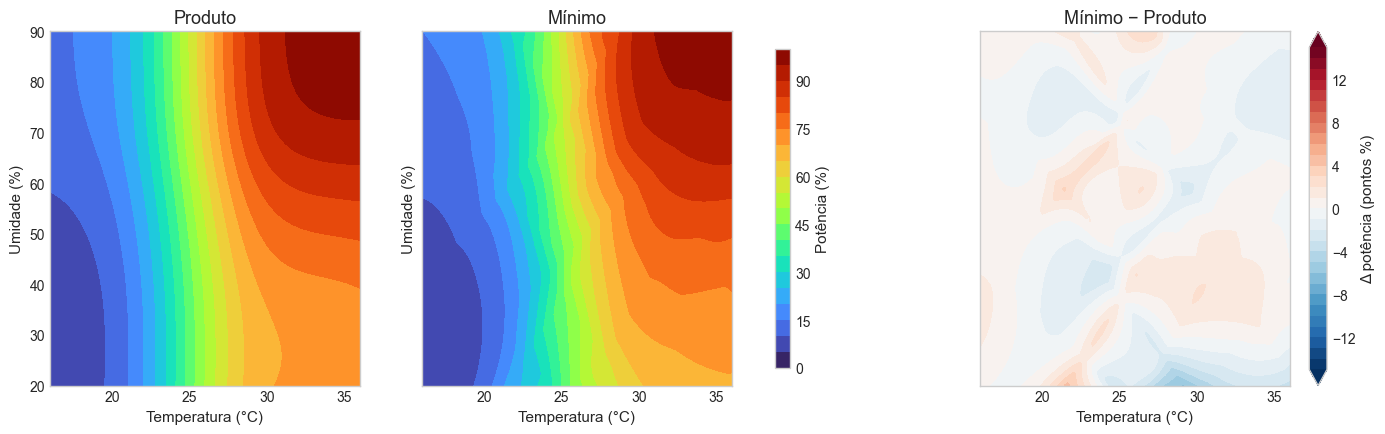

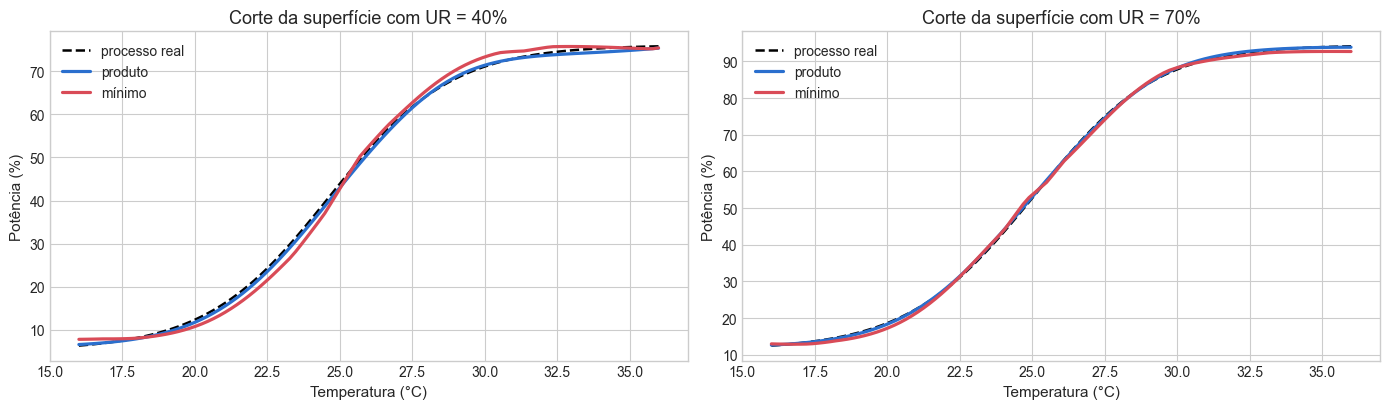

In [21]:
anfis_min = NeuroFuzzy([3, 3], operador="min").fit(X_treino, y_treino)
Z_prod, Z_min = superficie(anfis), superficie(anfis_min)

def rugosidade(Z):
    # média das segundas diferenças: quanto maior, mais "quinas" a superfície tem
    return np.abs(np.diff(Z, 2, axis=0)).mean() + np.abs(np.diff(Z, 2, axis=1)).mean()

comp = pd.DataFrame({
    "Produto": {**calcular_metricas(y_teste, anfis.predict(X_teste)),
                "RMSE vs. processo real": np.sqrt(np.mean((Z_prod - Z_real) ** 2)),
                "rugosidade": rugosidade(Z_prod), "MSE treino": anfis.historico[-1]},
    "Mínimo": {**calcular_metricas(y_teste, anfis_min.predict(X_teste)),
               "RMSE vs. processo real": np.sqrt(np.mean((Z_min - Z_real) ** 2)),
               "rugosidade": rugosidade(Z_min), "MSE treino": anfis_min.historico[-1]},
}).T
print("(RMSE vs. processo real calculado na grade 100×100 de toda a região operacional)")
display(comp.round(4))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharex=True, sharey=True)
for ax, (tit, Z) in zip(axes[:2], [("Produto", Z_prod), ("Mínimo", Z_min)]):
    mapa = ax.contourf(TT, HH, Z, levels=np.linspace(0, 100, 21), cmap="turbo", vmin=0, vmax=100)
    ax.set(title=tit, xlabel="Temperatura (°C)", ylabel="Umidade (%)")
fig.colorbar(mapa, ax=axes[:2], label="Potência (%)", shrink=0.9)
dif = axes[2].contourf(TT, HH, Z_min - Z_prod, levels=np.linspace(-15, 15, 31), cmap="RdBu_r", extend="both")
axes[2].set(title="Mínimo − Produto", xlabel="Temperatura (°C)")
fig.colorbar(dif, ax=axes[2], label="Δ potência (pontos %)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, ur in zip(axes, [40.0, 70.0]):
    Xp = normalizar_entradas(t_grid, np.full_like(t_grid, ur))
    ax.plot(t_grid, processo_sem_ruido(t_grid, ur), "k--", lw=1.8, label="processo real")
    ax.plot(t_grid, anfis.predict(Xp), lw=2.3, color=CORES[0], label="produto")
    ax.plot(t_grid, anfis_min.predict(Xp), lw=2.3, color=CORES[2], label="mínimo")
    ax.set(title=f"Corte da superfície com UR = {ur:.0f}%", xlabel="Temperatura (°C)", ylabel="Potência (%)")
    ax.legend()
plt.tight_layout()
plt.show()

**Análise.**

| | RMSE teste | RMSE vs. processo real (grade) | rugosidade | MSE treino |
|---|---|---|---|---|
| Produto | 2,73 | 0,49 | 0,043 | 6,08 |
| Mínimo | 3,02 | 1,19 | 0,084 | 6,83 |

O mínimo é **pior nas quatro medidas**, embora o R² continue alto (0,989 contra 0,991). O erro contra o
processo real é 2,4 vezes maior e a superfície é 2 vezes mais "rugosa".

*Forma da superfície.* Com o produto, as curvas de nível são suaves. Com o mínimo aparecem
**facetas e quinas** (região de 25–26 °C e de 31–32 °C), e nos cortes com UR = 40% há um degrau em
≈ 25,5 °C e um "ombro" achatado depois de 31 °C. A diferença Mínimo − Produto fica em poucos pontos na
maior parte da região, chegando a cerca de 6 pontos nos cantos.

*Por quê.* Em $\min(\mu_T,\mu_H)$ só **uma** das entradas conta em cada ponto: aquela cuja pertinência
é menor. Onde $\mu_T<\mu_H$, a umidade não tem influência nenhuma sobre aquela regra, e vice-versa. A
superfície é definida por pedaços, com derivada descontínua ao longo da curva $\mu_T=\mu_H$. O
produto mistura as duas entradas em todo o domínio, então é suave e as duas sempre contribuem.

*Quando usar cada um.* O mínimo tem leitura clássica ("a regra vale tanto quanto seu antecedente mais
fraco") e é barato em hardware, mas para **aprendizado por otimização** o produto é preferível por ser
diferenciável.

---
## Exercício 4 — Poda de regras

> *Remova regras com ativação média inferior a 2% e reavalie o modelo.*

Ativação média = média, no treino, do peso normalizado $\bar w_i$ da regra. Como
$\sum_i \bar w_i = 1$, a média das 9 regras é 11,1%. Para diferenciar "raramente ativa" de
"raramente decisiva", acrescento a ativação máxima e a fração de amostras em que a regra é
a **dominante** (maior $\bar w_i$).

Três formas de reavaliar o modelo podado:

- **A** — só remove a regra (renormaliza os pesos, sem reajustar nada);
- **B** — remove e reestima os consequentes (premissas fixas);
- **C** — remove e retreina o modelo inteiro a partir das premissas atuais.

In [22]:
W_tr = anfis.pesos(X_treino)
dominante = np.bincount(W_tr.argmax(axis=1), minlength=9) / len(W_tr)

tabela_ativ = pd.DataFrame({
    "regra": np.arange(1, 10),
    "temperatura": np.repeat(TERMOS_T, 3),
    "umidade": TERMOS_H * 3,
    "consequente_pct": anfis.coef[:, 0],
    "ativ_média_%": 100 * W_tr.mean(axis=0),
    "ativ_máx_%": 100 * W_tr.max(axis=0),
    "dominante_%": 100 * dominante,
})
display(tabela_ativ.sort_values("ativ_média_%").round(2).reset_index(drop=True))
print(f"Menor ativação média: {tabela_ativ['ativ_média_%'].min():.2f}%  →  "
      f"regras abaixo de 2%: {(tabela_ativ['ativ_média_%'] < 2).sum()}")

,regra,temperatura,umidade,consequente_pct,ativ_média_%,ativ_máx_%,dominante_%
0,7,quente,seca,63.83,3.21,37.43,5.71
1,4,confortável,seca,79.13,5.64,38.88,4.76
2,8,quente,adequada,68.03,5.89,35.99,6.86
3,5,confortável,adequada,77.29,9.41,36.32,8.57
4,1,fria,seca,4.86,10.35,60.92,15.05
5,9,quente,úmida,100.00,11.34,62.13,14.10
6,2,fria,adequada,4.01,14.60,56.43,12.19
7,6,confortável,úmida,99.96,16.88,62.63,13.14
8,3,fria,úmida,13.47,22.69,98.47,19.62


Menor ativação média: 3.21%  →  regras abaixo de 2%: 0


In [23]:
def podar_e_avaliar(limiar):
    mascara = W_tr.mean(axis=0) >= limiar
    A = copy.copy(anfis); A.ativas = mascara
    B = copy.copy(A); B.refit_consequentes(X_treino, y_treino)
    C = NeuroFuzzy([3, 3], ativas=mascara).fit(X_treino, y_treino, theta0=anfis.theta)
    linha = {"limiar": f"{100 * limiar:.0f}%", "regras removidas": [int(i + 1) for i in np.where(~mascara)[0]],
             "regras finais": int(mascara.sum())}
    for nome, mod in [("A: só remove", A), ("B: + reajusta consequentes", B), ("C: + retreina", C)]:
        linha[f"RMSE teste {nome}"] = np.sqrt(mean_squared_error(y_teste, mod.predict(X_teste)))
    linha["erro máx. |e| (A)"] = np.abs(y_teste - A.predict(X_teste)).max()
    return linha

rmse_ref = np.sqrt(mean_squared_error(y_teste, anfis.predict(X_teste)))
tabela_poda = pd.DataFrame([podar_e_avaliar(l) for l in [0.02, 0.04, 0.06, 0.10]]).set_index("limiar")
print(f"RMSE de teste do modelo completo (9 regras): {rmse_ref:.3f} | erro máx. |e|: "
      f"{np.abs(y_teste - anfis.predict(X_teste)).max():.2f}")
display(tabela_poda.round(3))

RMSE de teste do modelo completo (9 regras): 2.726 | erro máx. |e|: 7.83


,regras removidas,regras finais,RMSE teste A: só remove,RMSE teste B: + reajusta consequentes,RMSE teste C: + retreina,erro máx. |e| (A)
limiar,,,,,,
2%,[],9,2.726,2.726,2.724,7.828
4%,[7],8,2.853,2.738,2.742,9.913
6%,"[4, 7, 8]",6,5.881,4.734,2.949,19.747
10%,"[4, 5, 7, 8]",5,11.964,8.406,4.465,34.546


**Análise.**

1. **Com o critério literal (< 2%) nenhuma regra é podada.** A menor ativação média é 3,2% (regra 7,
   quente/seca). O treino já distribuiu os dados entre as regras: a média é 11,1% e as mais raras ainda
   cobrem 3–6%. Por isso o modelo "podado" é o próprio modelo completo (RMSE 2,726).
2. **Varredura de limiares** (RMSE de teste do modelo completo: 2,726; erro máximo 7,8):

   | limiar | regras removidas | A: só remove | B: + reajusta consequentes | C: + retreina | erro máx. (A) |
   |---|---|---|---|---|---|
   | 2% | nenhuma | 2,726 | 2,726 | 2,724 | 7,8 |
   | 4% | 7 | 2,853 | 2,738 | 2,742 | 9,9 |
   | 6% | 4, 7, 8 | 5,881 | 4,734 | 2,949 | 19,7 |
   | 10% | 4, 5, 7, 8 | 11,964 | 8,406 | 4,465 | 34,5 |

3. **Ativação média baixa não significa regra inútil.** A regra 7 tem média de 3,2%, mas é a
   regra **dominante em 5,7% das amostras** (ativação máxima de 37%): cobre uma região própria
   (temperatura alta com umidade baixa) e tem consequente (64%) diferente dos vizinhos. Removê-la
   sem reajustar já aumenta o erro máximo de 7,8 para 9,9. Uma regra pouco ativada em média pode
   ser **localizada**, não dispensável. Critérios melhores são a dominância e o aumento do erro de
   validação ao remover a regra.
4. **Podar sem reajustar é perigoso.** Os vizinhos absorvem a região da regra removida (os pesos são
   renormalizados) com consequentes ajustados para outras regiões. Reestimar os consequentes (B) ou
   retreinar (C) recupera boa parte do prejuízo: com 6 regras, o RMSE passa de 5,88 (A) para 2,95 (C),
   ou seja, 8% pior que o modelo completo. Neste problema, 3 das 9 regras podem sair com custo
   moderado, mas **só com reajuste**.

---
## Exercício 5 — Sugeno de primeira ordem

> *Implemente consequentes lineares $p_i x_1+q_i x_2+r_i$.*

Com as premissas fixas, a saída $\hat y=\sum_i \bar w_i (p_i x_1+q_i x_2+r_i)$ continua
linear nos 27 coeficientes, então o mesmo passo de mínimos quadrados regularizados resolve
o problema (a `NeuroFuzzy(ordem=1)` monta a matriz $[\bar w_i x_1,\ \bar w_i x_2,\ \bar w_i]$).
A saída é limitada a [0, 100]. Como a primeira ordem tem mais parâmetros, incluo também
uma versão 2×2 termos, com número de parâmetros próximo ao da ordem zero 3×3.

In [24]:
anfis1 = NeuroFuzzy([3, 3], ordem=1).fit(X_treino, y_treino)
anfis1_2x2 = NeuroFuzzy([2, 2], ordem=1).fit(X_treino, y_treino)

candidatos = {
    "Ordem 0 — 3×3 (aula)": anfis,
    "Ordem 1 — 3×3": anfis1,
    "Ordem 1 — 2×2": anfis1_2x2,
}
linhas = []
for nome, mod in candidatos.items():
    linhas.append({
        "modelo": nome, "regras": mod.n_regras, "parâmetros": mod.n_parametros,
        "RMSE treino": np.sqrt(mean_squared_error(y_treino, mod.predict(X_treino))),
        "RMSE teste": np.sqrt(mean_squared_error(y_teste, mod.predict(X_teste))),
        "R² teste": r2_score(y_teste, mod.predict(X_teste)),
        "RMSE vs. processo real": np.sqrt(mean_squared_error(ideal_teste, mod.predict(X_teste))),
    })
linhas.append({"modelo": "MLP (12 tanh)", "regras": "—", "parâmetros": 12 * 2 + 12 + 12 + 1,
               "RMSE treino": np.sqrt(mean_squared_error(y_treino, np.clip(mlp.predict(X_treino), 0, 100))),
               "RMSE teste": np.sqrt(mean_squared_error(y_teste, pred_mlp)),
               "R² teste": r2_score(y_teste, pred_mlp),
               "RMSE vs. processo real": np.sqrt(mean_squared_error(ideal_teste, pred_mlp))})
tabela_ordem = pd.DataFrame(linhas).set_index("modelo")
display(tabela_ordem.round(3))

# Consequentes lineares aprendidos (3×3), em unidades físicas
R = anfis1.n_regras
p, q, r = (anfis1.coef[k * R:(k + 1) * R, 0] for k in range(3))
c_n, _ = anfis1.separar(anfis1.theta)
(ct1, _), (ch1, _) = centros_fisicos(anfis1)
linhas_regra = []
for i in range(R):
    it, ih = divmod(i, 3)
    f_centro = p[i] * c_n[0][it] + q[i] * c_n[1][ih] + r[i]
    linhas_regra.append({
        "regra": i + 1, "temperatura": TERMOS_T[it], "umidade": TERMOS_H[ih],
        "∂P/∂T (%/°C)": p[i] / (T_MAX - T_MIN), "∂P/∂UR (%/pp)": q[i] / (H_MAX - H_MIN),
        "P no centro da regra (%)": f_centro,
    })
display(pd.DataFrame(linhas_regra).round(2))

,regras,parâmetros,RMSE treino,RMSE teste,R² teste,RMSE vs. processo real
modelo,,,,,,
Ordem 0 — 3×3 (aula),9,21,2.465,2.726,0.991,0.461
Ordem 1 — 3×3,9,39,2.386,2.807,0.990,0.634
Ordem 1 — 2×2,4,20,2.427,2.793,0.991,0.588
MLP (12 tanh),—,49,2.424,2.877,0.990,0.691


,regra,temperatura,umidade,∂P/∂T (%/°C),∂P/∂UR (%/pp),P no centro da regra (%)
0,1,fria,seca,-1.04,-0.26,-9.21
1,2,fria,adequada,-3.19,-0.05,0.81
2,3,fria,úmida,-1.40,0.16,0.15
3,4,confortável,seca,-0.79,0.18,77.52
4,5,confortável,adequada,-0.11,0.43,99.24
5,6,confortável,úmida,0.34,0.30,96.79
6,7,quente,seca,-0.53,-0.39,67.51
7,8,quente,adequada,1.31,0.16,105.79
8,9,quente,úmida,1.44,0.59,100.71


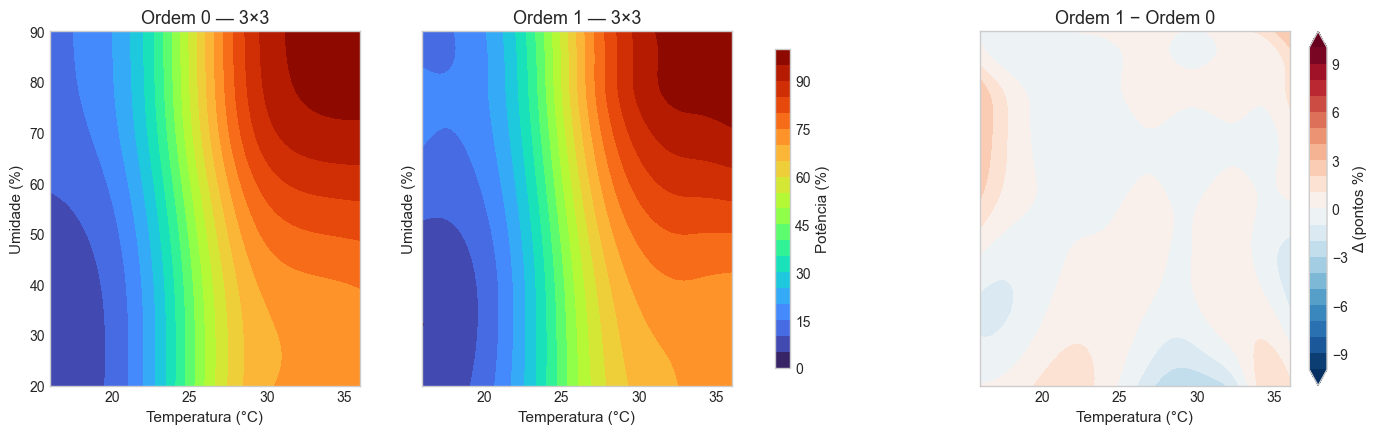

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharex=True, sharey=True)
Z0, Z1 = superficie(anfis), superficie(anfis1)
for ax, (tit, Z) in zip(axes[:2], [("Ordem 0 — 3×3", Z0), ("Ordem 1 — 3×3", Z1)]):
    mapa = ax.contourf(TT, HH, Z, levels=np.linspace(0, 100, 21), cmap="turbo", vmin=0, vmax=100)
    ax.set(title=tit, xlabel="Temperatura (°C)", ylabel="Umidade (%)")
fig.colorbar(mapa, ax=axes[:2], label="Potência (%)", shrink=0.9)
dif = axes[2].contourf(TT, HH, Z1 - Z0, levels=np.linspace(-10, 10, 21), cmap="RdBu_r", extend="both")
axes[2].set(title="Ordem 1 − Ordem 0", xlabel="Temperatura (°C)")
fig.colorbar(dif, ax=axes[2], label="Δ (pontos %)")
plt.show()

**Análise.**

| modelo | regras | parâmetros | RMSE treino | RMSE teste | RMSE vs. processo real |
|---|---|---|---|---|---|
| Ordem 0 (3×3) | 9 | 21 | 2,465 | **2,726** | **0,461** |
| Ordem 1 (3×3) | 9 | 39 | 2,386 | 2,807 | 0,634 |
| Ordem 1 (2×2) | 4 | 20 | 2,427 | 2,793 | 0,588 |
| MLP (12 tanh) | — | 49 | 2,424 | 2,877 | 0,691 |

*Desempenho.* A primeira ordem se ajusta **melhor ao treino** (2,386 contra 2,465) e **pior ao teste**
(2,807 contra 2,726) e ao processo real (0,634 contra 0,461): os 18 parâmetros extras ajustam ruído
(o erro de treino fica abaixo de σ = 2,5). A superfície do problema é uma sigmoide suave, que 9
constantes com interpolação fuzzy já capturam, então a descrição localmente linear não traz ganho.
Com o mesmo orçamento de parâmetros, a versão de 4 regras (20 parâmetros) chega a 2,793, quase o
mesmo que a de 9 regras de ordem zero, com menos regras para auditar. A superfície de ordem 1 difere
da de ordem 0 em poucos pontos, com desvios maiores nas bordas, onde o consequente linear extrapola.

*Interpretação.* Os consequentes viram modelos lineares locais e a tabela mostra o custo:

- valores **fora do intervalo físico** no centro da regra (−9,2% em "fria/seca"; 105,8% em
  "quente/adequada");
- inclinações com **sinal contrário ao esperado**: ∂P/∂T = −3,19 %/°C em "fria/adequada" e
  −0,53 %/°C em "quente/seca". Cada regra só faz sentido em conjunto com as vizinhas, que
  compensam o termo linear na mistura.

Quando os coeficientes são coerentes, como em "quente/úmida" (+1,44 %/°C e +0,59 %/pp), eles são
diretamente legíveis. A primeira ordem compensa quando poucas regras precisam descrever regimes
realmente inclinados. Aqui isso não ocorre, e a ordem zero é melhor e mais auditável.

---
## Exercício 6 — Restrições nos centros

> *Retire os limites dos centros. Verifique se os termos ainda podem ser chamados de
> baixo, médio e alto.*

Faço dois testes:

1. **Mesma inicialização da aula, sem limites nos centros** (as larguras continuam
   limitadas).
2. **Dez inicializações aleatórias** (centros sorteados em [0, 1], sem limites): o
   otimizador é livre para colocar "fria" acima de "quente".

O critério para o nome ser válido é: $c_{\text{baixo}}<c_{\text{médio}}<c_{\text{alto}}$ em
cada entrada.

In [26]:
def ordenado(centros):
    return bool(np.all(np.diff(centros) > 0))

restrito = anfis
livre = NeuroFuzzy([3, 3], centros_livres=True).fit(X_treino, y_treino)

def resumo(nome, mod):
    (ct, st), (ch, sh) = centros_fisicos(mod)
    cons = mod.coef[:, 0].reshape(3, 3)
    return {
        "modelo": nome,
        "centros T (°C)": ct.round(1).tolist(), "centros UR (%)": ch.round(1).tolist(),
        "T ordenada": ordenado(ct), "UR ordenada": ordenado(ch),
        "RMSE teste": np.sqrt(mean_squared_error(y_teste, mod.predict(X_teste))),
        "consequentes crescem c/ T": bool(np.all(np.diff(cons, axis=0) >= -1e-9)),
    }

display(pd.DataFrame([resumo("com limites (aula)", restrito), resumo("sem limites (mesma init.)", livre)]).set_index("modelo").round(3))

nomes_c = [f"T {n}" for n in TERMOS_T] + [f"UR {n}" for n in TERMOS_H]
lim_c = restrito.limites()[:6]
no_limite = [nomes_c[k] for k, (a, b_) in enumerate(lim_c)
             if np.isclose(restrito.theta[k], a, atol=1e-3) or np.isclose(restrito.theta[k], b_, atol=1e-3)]
print("Centros do modelo COM limites que terminaram encostados num limite:", no_limite)

,centros T (°C),centros UR (%),T ordenada,UR ordenada,RMSE teste,consequentes crescem c/ T
modelo,,,,,,
com limites (aula),"[21.0, 28.5, 31.8]","[31.8, 44.9, 72.5]",True,True,2.726,False
sem limites (mesma init.),"[20.3, 32.1, 33.0]","[-3.9, 45.5, 59.1]",True,True,2.716,False


Centros do modelo COM limites que terminaram encostados num limite: ['T fria', 'UR úmida']


In [27]:
rng6 = np.random.default_rng(SEED)
linhas, modelos_aleat = [], []
for k in range(10):
    ini = NeuroFuzzy([3, 3], centros_livres=True)
    th0 = ini.theta_inicial().copy()
    th0[:6] = rng6.uniform(0.0, 1.0, 6)                # centros aleatórios
    mod = NeuroFuzzy([3, 3], centros_livres=True).fit(X_treino, y_treino, theta0=th0)
    modelos_aleat.append(mod)
    r_ = resumo(f"início aleatório {k + 1}", mod)
    r_["MSE treino"] = mod.historico[-1]
    linhas.append(r_)
tab_aleat = pd.DataFrame(linhas).set_index("modelo")
display(tab_aleat.round(3))
ok_ambos = (tab_aleat["T ordenada"] & tab_aleat["UR ordenada"]).sum()
print(f"Inicializações em que TODOS os termos ficaram ordenados: {ok_ambos}/10")
print(f"Ordem de temperatura correta: {int(tab_aleat['T ordenada'].sum())}/10 | "
      f"ordem de umidade correta: {int(tab_aleat['UR ordenada'].sum())}/10")
fora_h = sum(any((v < H_MIN) or (v > H_MAX) for v in centros_fisicos(m)[1][0]) for m in modelos_aleat)
fora_t = sum(any((v < T_MIN) or (v > T_MAX) for v in centros_fisicos(m)[0][0]) for m in modelos_aleat)
print(f"Com algum centro FORA do universo físico — umidade [{H_MIN:.0f}, {H_MAX:.0f}]%: {fora_h}/10 | "
      f"temperatura [{T_MIN:.0f}, {T_MAX:.0f}] °C: {fora_t}/10")
print(f"Inicializações com RMSE de teste ≤ 1,10 × o do modelo restrito: "
      f"{(tab_aleat['RMSE teste'] <= 1.10 * rmse_ref).sum()}/10")

,centros T (°C),centros UR (%),T ordenada,UR ordenada,RMSE teste,consequentes crescem c/ T,MSE treino
modelo,,,,,,,
início aleatório 1,"[31.4, 20.8, 32.3]","[59.8, 45.9, 78.9]",False,False,2.713,False,6.072
início aleatório 2,"[31.6, 32.5, 20.5]","[50.1, 46.9, 137.4]",False,False,2.711,False,6.037
início aleatório 3,"[33.3, 32.5, 19.9]","[46.5, 58.5, -5.3]",False,False,2.715,False,6.052
início aleatório 4,"[35.0, 17.2, 35.2]","[47.9, 89.5, 64.8]",False,False,2.709,False,6.112
início aleatório 5,"[32.1, 21.3, 31.1]","[-10.5, 44.2, 61.1]",False,True,2.716,False,6.053
início aleatório 6,"[22.2, 26.4, 19.4]","[49.2, 62.4, -13.7]",False,False,2.735,False,5.991
início aleatório 7,"[19.1, 27.1, 22.1]","[62.0, 52.4, 123.2]",False,False,2.712,False,5.969
início aleatório 8,"[34.1, 18.4, 34.3]","[60.6, 44.8, 11.7]",False,False,2.715,False,6.051
início aleatório 9,"[25.7, 20.2, 22.9]","[52.9, 108.8, 61.8]",False,False,2.715,False,5.954


Inicializações em que TODOS os termos ficaram ordenados: 0/10
Ordem de temperatura correta: 0/10 | ordem de umidade correta: 1/10
Com algum centro FORA do universo físico — umidade [20, 90]%: 8/10 | temperatura [16, 36] °C: 0/10
Inicializações com RMSE de teste ≤ 1,10 × o do modelo restrito: 10/10


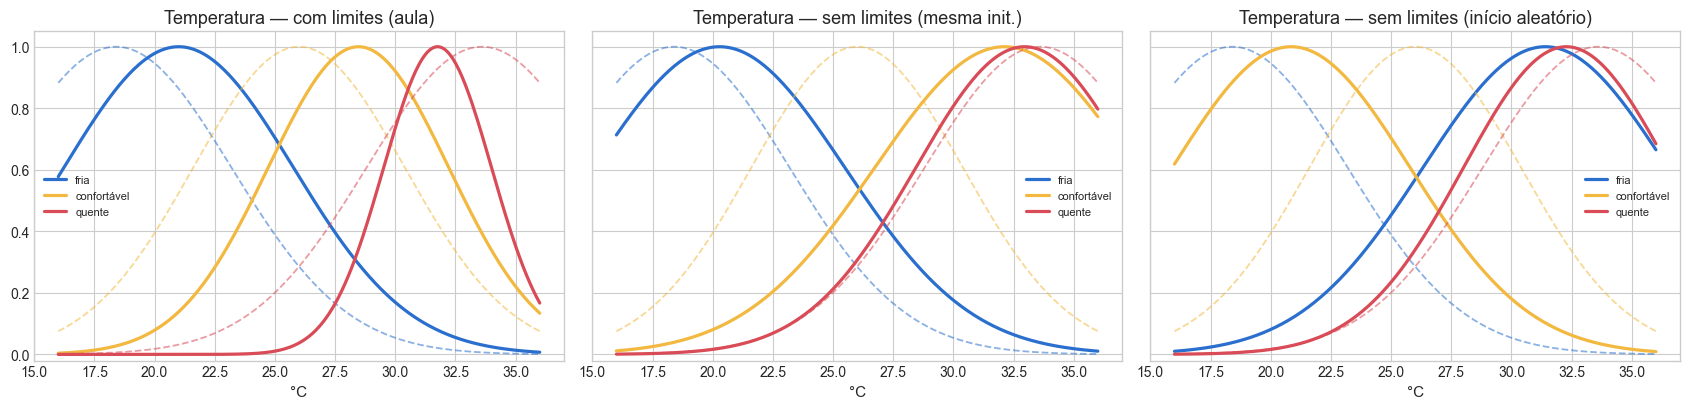

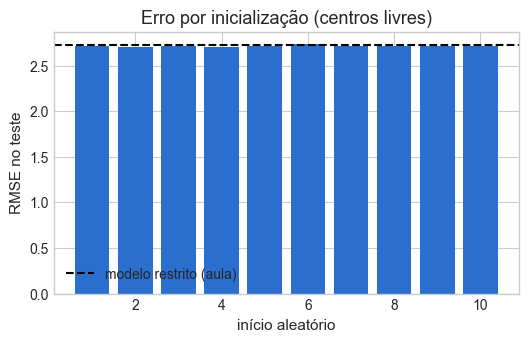

In [28]:
# Mostra o pior caso semântico: uma inicialização com termos fora de ordem
desordem = [m for m in modelos_aleat if not (ordenado(centros_fisicos(m)[0][0]) and ordenado(centros_fisicos(m)[1][0]))]
exemplo = desordem[0] if desordem else livre
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), sharey=True)
plotar_pertinencias(axes[0], restrito, 0, TERMOS_T, "Temperatura — com limites (aula)")
plotar_pertinencias(axes[1], livre, 0, TERMOS_T, "Temperatura — sem limites (mesma init.)")
plotar_pertinencias(axes[2], exemplo, 0, TERMOS_T,
                    "Temperatura — sem limites (início aleatório)" if desordem else "sem caso desordenado")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(range(1, 11), tab_aleat["RMSE teste"], color=CORES[0])
ax.axhline(rmse_ref, color="k", ls="--", label="modelo restrito (aula)")
ax.set(xlabel="início aleatório", ylabel="RMSE no teste", title="Erro por inicialização (centros livres)")
ax.legend()
plt.show()

**Análise.** Os limites nos centros custam **zero de acurácia** e é isso que sustenta o significado
dos termos.

*Mesma inicialização, sem limites.* O RMSE de teste mal muda (2,716 contra 2,726), mas as
pertinências ficam ruins (figura):

- "confortável" (32,1 °C) e "quente" (33,0 °C) ficam a menos de 1 °C uma da outra, com curvas quase
  idênticas: dois nomes para o mesmo conceito;
- "seca" fica com centro em **−3,9% de UR**, fora do universo físico (20–90%). Numericamente os
  centros ainda estão em ordem crescente, mas o termo deixou de descrever uma região real.

*Dez inicializações aleatórias sem limites.* A ordem de temperatura foi correta em 0 de 10 e a de
umidade em 1 de 10, ou seja, **nenhuma** manteve os três termos "baixo < médio < alto" nas duas
entradas. Em **8 das 10** pelo menos um centro de umidade saiu do universo físico [20, 90]% (nos de temperatura, 0 de 10). O
RMSE de teste, porém, ficou entre 2,71 e 2,74 em todas, praticamente igual ao do modelo restrito. A função de
custo tem muitos mínimos equivalentes, que diferem só por **permutar os rótulos**: o otimizador não
tem por que preferir "fria" à esquerda. Na figura, num início aleatório, o termo chamado "fria" ficou
centrado em 31 °C e o "confortável" em 21 °C.

**Resposta à pergunta.** Sem os limites, **não** se pode chamar os termos de baixo, médio e alto: a
ordem, a separação e o domínio deixam de ser garantidos, e o modelo não ganha nada em troca.

*Ressalva importante.* Os limites são necessários, mas **não suficientes**. Mesmo o modelo restrito
tem dois centros encostados num limite ("T fria" e "UR úmida"), e seus consequentes **não** crescem com a
temperatura: "confortável" (79 / 77 / 100%) supera "quente/seca" e "quente/adequada" (64 / 68%), pois
"confortável" migrou para 28,5 °C. Restringir a ordem dos centros preserva a ordem dos rótulos, mas
não a coerência das regras; para isso seria preciso impor também consequentes monotônicos em T e UR.

---
## Exercício 7 — Robótica: velocidades das rodas

> *Adapte o modelo para aprender velocidades das rodas a partir das distâncias
> esquerda, frente e direita do Notebook 6.*

**Premissa:** o Notebook 6 não está disponível. Simulo o problema que ele descreve:
sensores de distância (5 a 100 cm) à esquerda, à frente e à direita, e duas saídas, a
velocidade da roda esquerda e da direita (−100% a +100% da velocidade máxima). O
"especialista" é um controlador de desvio de obstáculos com esta lógica:

- avança tanto mais rápido quanto mais livre estiver a frente;
- desvia da parede lateral mais próxima (vira para o lado mais livre);
- com obstáculo à frente, para de avançar e gira no lugar para o lado mais livre.

Roda esquerda mais rápida que a direita = curva à direita. Adicionei ruído (σ = 4)
nas velocidades. A adaptação do modelo:

- 3 entradas × 3 termos (**perto, média, longe**) = **27 regras**;
- **duas saídas**: os consequentes de cada roda são estimados separadamente (o mesmo passo
  de mínimos quadrados) e compartilham as premissas (centros e larguras);
- consequentes limitados a [−100, 100].

In [29]:
D_MIN, D_MAX = 5.0, 100.0
TERMOS_D = ["perto", "média", "longe"]

def controlador_referencia(esq, frente, dir_):
    livre_frente = sigmoid((frente - 35.0) / 9.0)
    avanco = 85.0 * livre_frente
    giro = (30.0 * np.tanh((dir_ - esq) / 30.0)
            + 60.0 * (1.0 - livre_frente) * np.tanh((dir_ - esq) / 15.0))
    v_esq = np.clip(avanco + giro, -100, 100)
    v_dir = np.clip(avanco - giro, -100, 100)
    return np.column_stack([v_esq, v_dir])

rng7 = np.random.default_rng(SEED)
n7 = 1500
dist = rng7.uniform(D_MIN, D_MAX, (n7, 3))                       # esquerda, frente, direita
vel_ideal = controlador_referencia(dist[:, 0], dist[:, 1], dist[:, 2])
vel_obs = np.clip(vel_ideal + rng7.normal(0, 4.0, vel_ideal.shape), -100, 100)

norm_d = lambda d: (np.asarray(d, float) - D_MIN) / (D_MAX - D_MIN)
X7 = norm_d(dist)
i7_tr, i7_te = train_test_split(np.arange(n7), test_size=0.25, random_state=SEED)

LIM_VEL = (-100.0, 100.0)
robo_ini = NeuroFuzzy([3, 3, 3], lim_saida=LIM_VEL).sem_treino(X7[i7_tr], vel_obs[i7_tr])
t0 = time.time()
robo = NeuroFuzzy([3, 3, 3], lim_saida=LIM_VEL).fit(X7[i7_tr], vel_obs[i7_tr])
print(f"Treino do neurofuzzy (27 regras, 2 saídas): {time.time() - t0:.1f} s, "
      f"MSE {robo.historico[0]:.1f} → {robo.historico[-1]:.1f}")
robo_300 = NeuroFuzzy([3, 3, 3], lim_saida=LIM_VEL).fit(X7[i7_tr], vel_obs[i7_tr], maxiter=300)
rmse_300 = np.sqrt(np.mean((robo_300.predict(X7[i7_te]) - vel_obs[i7_te]) ** 2))
rmse_100 = np.sqrt(np.mean((robo.predict(X7[i7_te]) - vel_obs[i7_te]) ** 2))
print(f"Checagem de convergência (27 regras): RMSE de teste com 100 iterações = {rmse_100:.2f}; "
      f"com até 300 = {rmse_300:.2f} (parou em {robo_300.res.nit} iterações)")
t0 = time.time()
robo4 = NeuroFuzzy([4, 4, 4], lim_saida=LIM_VEL).fit(X7[i7_tr], vel_obs[i7_tr])
print(f"Treino do neurofuzzy 4×4×4 (64 regras): {time.time() - t0:.0f} s, "
      f"MSE {robo4.historico[0]:.1f} → {robo4.historico[-1]:.1f}")
robo_mlp = MLPRegressor(hidden_layer_sizes=(20,), activation="tanh", solver="lbfgs", alpha=1e-3,
                        max_iter=2000, tol=1e-6, random_state=SEED).fit(X7[i7_tr], vel_obs[i7_tr])

preds7 = {
    "Premissas iniciais + MQ (27 regras)": (robo_ini.predict(X7[i7_te]), robo_ini.n_parametros),
    "Neurofuzzy híbrido (27 regras)": (robo.predict(X7[i7_te]), robo.n_parametros),
    "Neurofuzzy híbrido 4 termos (64 regras)": (robo4.predict(X7[i7_te]), robo4.n_parametros),
    "MLP (20 tanh)": (np.clip(robo_mlp.predict(X7[i7_te]), *LIM_VEL), 3 * 20 + 20 + 20 * 2 + 2),
}
linhas = []
for nome, (p, n_par) in preds7.items():
    linhas.append({
        "modelo": nome, "parâmetros": n_par,
        "RMSE roda esq.": np.sqrt(mean_squared_error(vel_obs[i7_te, 0], p[:, 0])),
        "RMSE roda dir.": np.sqrt(mean_squared_error(vel_obs[i7_te, 1], p[:, 1])),
        "R² esq.": r2_score(vel_obs[i7_te, 0], p[:, 0]),
        "R² dir.": r2_score(vel_obs[i7_te, 1], p[:, 1]),
        "RMSE vs. controlador real": np.sqrt(np.mean((vel_ideal[i7_te] - p) ** 2)),
    })
display(pd.DataFrame(linhas).set_index("modelo").round(3))
(cd_, sd_) = robo.separar(robo.theta)
print("Centros aprendidos (cm) — esq:", (D_MIN + cd_[0] * (D_MAX - D_MIN)).round(0),
      "| frente:", (D_MIN + cd_[1] * (D_MAX - D_MIN)).round(0),
      "| dir:", (D_MIN + cd_[2] * (D_MAX - D_MIN)).round(0))

Treino do neurofuzzy (27 regras, 2 saídas): 13.3 s, MSE 174.3 → 80.2
Checagem de convergência (27 regras): RMSE de teste com 100 iterações = 8.68; com até 300 = 8.68 (parou em 113 iterações)
Treino do neurofuzzy 4×4×4 (64 regras): 41 s, MSE 50.4 → 29.4


,parâmetros,RMSE roda esq.,RMSE roda dir.,R² esq.,R² dir.,RMSE vs. controlador real
modelo,,,,,,
Premissas iniciais + MQ (27 regras),72,12.708,12.536,0.930,0.935,12.339
Neurofuzzy híbrido (27 regras),72,8.424,8.929,0.969,0.967,7.978
Neurofuzzy híbrido 4 termos (64 regras),152,5.421,5.193,0.987,0.989,4.153
MLP (20 tanh),122,5.168,5.074,0.988,0.989,3.493


Centros aprendidos (cm) — esq: [13. 45. 84.] | frente: [25. 42. 76.] | dir: [ 13.  63. 100.]


In [30]:
# Auditoria: cenários interpretáveis + simetria esquerda/direita
cen = pd.DataFrame({
    "cenário": ["corredor livre", "parede à esquerda", "parede à direita",
                "obstáculo à frente, esq. mais livre", "obstáculo à frente, dir. mais livre", "encurralado"],
    "esq (cm)": [60, 10, 60, 70, 30, 10], "frente (cm)": [90, 80, 80, 12, 12, 10], "dir (cm)": [60, 60, 10, 30, 70, 10],
})
Xc = norm_d(cen[["esq (cm)", "frente (cm)", "dir (cm)"]].values)
ref = controlador_referencia(*cen[["esq (cm)", "frente (cm)", "dir (cm)"]].values.T)
nf, ml = robo.predict(Xc), np.clip(robo_mlp.predict(Xc), *LIM_VEL)
for k, roda in enumerate(["esq", "dir"]):
    cen[f"ref {roda}"], cen[f"neurofuzzy {roda}"], cen[f"MLP {roda}"] = ref[:, k], nf[:, k], ml[:, k]
display(cen.round(0).astype({c: int for c in cen.columns if c != "cenário"}))

# simetria: v_esq(e, f, d) deveria ser igual a v_dir(d, f, e)
g = rng7.uniform(D_MIN, D_MAX, (4000, 3)); g_esp = g[:, [2, 1, 0]]
def assimetria(pred):
    return np.mean(np.abs(pred(norm_d(g))[:, 0] - pred(norm_d(g_esp))[:, 1]))
print("Erro médio de simetria |v_esq(e,f,d) − v_dir(d,f,e)| (pontos %):")
print(f"  controlador real: {np.mean(np.abs(controlador_referencia(*g.T)[:, 0] - controlador_referencia(*g_esp.T)[:, 1])):.2f}"
      f" | neurofuzzy 27 regras: {assimetria(robo.predict):.2f} | neurofuzzy 64 regras: {assimetria(robo4.predict):.2f}"
      f" | MLP: {assimetria(lambda A: np.clip(robo_mlp.predict(A), *LIM_VEL)):.2f}")

,cenário,esq (cm),frente (cm),dir (cm),ref esq,neurofuzzy esq,MLP esq,ref dir,neurofuzzy dir,MLP dir
0,corredor livre,60,90,60,85,82,83,85,82,81
1,parede à esquerda,10,80,60,100,99,100,56,49,60
2,parede à direita,60,80,10,56,56,61,100,99,97
3,"obstáculo à frente, esq. mais livre",70,12,30,-75,-69,-78,87,83,93
4,"obstáculo à frente, dir. mais livre",30,12,70,87,91,91,-75,-78,-81
5,encurralado,10,10,10,5,19,-2,5,-3,4


Erro médio de simetria |v_esq(e,f,d) − v_dir(d,f,e)| (pontos %):
  controlador real: 0.00 | neurofuzzy 27 regras: 6.06 | neurofuzzy 64 regras: 3.28 | MLP: 2.92


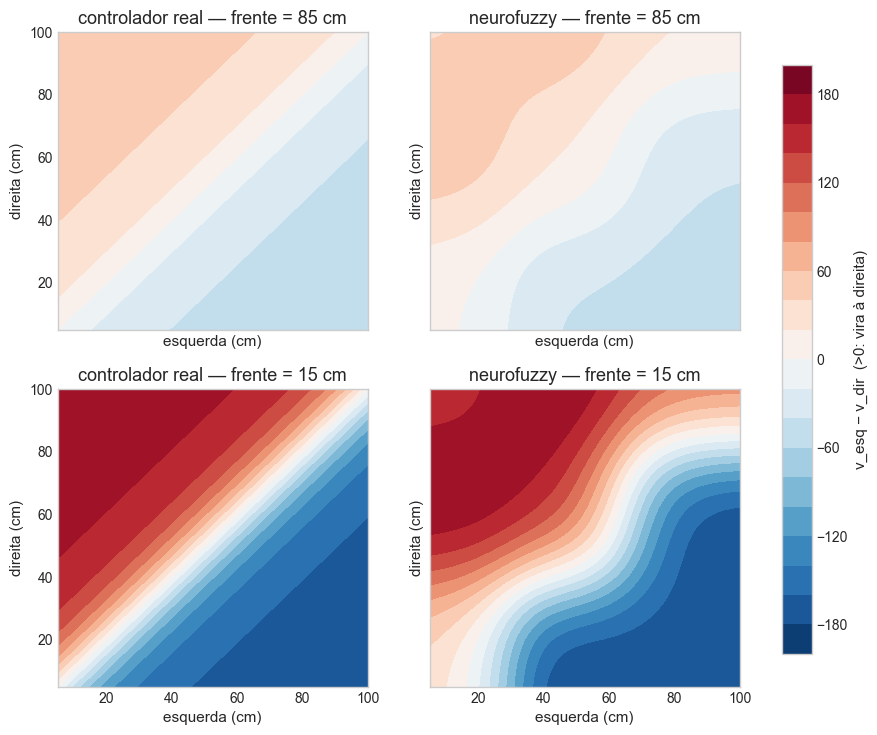

,esq,frente,dir,v_esq (%),v_dir (%),ativ. média (%)
0,perto,perto,perto,30.4,-16.3,2.6
1,perto,perto,média,100.0,-100.0,3.0
2,perto,perto,longe,84.3,-59.9,0.9
3,perto,média,perto,100.0,50.7,2.0
4,perto,média,média,100.0,16.9,2.1
5,perto,média,longe,100.0,47.5,0.7
6,perto,longe,perto,93.6,85.9,4.3
7,perto,longe,média,100.0,40.3,4.8
8,perto,longe,longe,97.6,63.5,2.1
9,média,perto,perto,-100.0,100.0,4.8


In [31]:
# Curva: giro = v_esq − v_dir em função de (esquerda, direita), com a frente livre e bloqueada
e_g, d_g = np.meshgrid(np.linspace(D_MIN, D_MAX, 80), np.linspace(D_MIN, D_MAX, 80))
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), sharex=True, sharey=True)
for r_, f_cm in enumerate([85.0, 15.0]):
    Xg = norm_d(np.column_stack([e_g.ravel(), np.full(e_g.size, f_cm), d_g.ravel()]))
    r_ref = controlador_referencia(e_g.ravel(), np.full(e_g.size, f_cm), d_g.ravel())
    for c_, (tit, Y) in enumerate([("controlador real", r_ref), ("neurofuzzy", robo.predict(Xg))]):
        giro = (Y[:, 0] - Y[:, 1]).reshape(e_g.shape)
        m_ = axes[r_, c_].contourf(e_g, d_g, giro, levels=np.linspace(-200, 200, 21), cmap="RdBu_r")
        axes[r_, c_].set(title=f"{tit} — frente = {f_cm:.0f} cm", xlabel="esquerda (cm)", ylabel="direita (cm)")
fig.colorbar(m_, ax=axes, label="v_esq − v_dir  (>0: vira à direita)", shrink=0.9)
plt.show()

# Consequentes das 27 regras (velocidade de cada roda)
tab7 = pd.DataFrame([
    {"esq": TERMOS_D[a], "frente": TERMOS_D[b], "dir": TERMOS_D[c],
     "v_esq (%)": robo.coef[9 * a + 3 * b + c, 0], "v_dir (%)": robo.coef[9 * a + 3 * b + c, 1],
     "ativ. média (%)": 100 * robo.ativacao_media(X7[i7_tr])[9 * a + 3 * b + c]}
    for a in range(3) for b in range(3) for c in range(3)
])
display(tab7.round(1))

**Análise.** (Dados simulados; o Notebook 6 não estava disponível. O piso de erro do ruído é 4.)

| modelo | parâmetros | RMSE esq. | RMSE dir. | RMSE vs. controlador real |
|---|---|---|---|---|
| Premissas iniciais + MQ (27 regras) | 72 | 12,71 | 12,54 | 12,34 |
| Neurofuzzy híbrido (27 regras) | 72 | 8,42 | 8,93 | 7,98 |
| Neurofuzzy híbrido, 4 termos (64 regras) | 152 | 5,42 | 5,19 | 4,15 |
| MLP (20 tanh) | 122 | 5,17 | 5,07 | 3,49 |

*Adaptação.* Com 3 entradas × 3 termos surgem 27 regras. Cada regra tem **dois consequentes**, um por
roda, estimados por mínimos quadrados separados sobre as mesmas premissas. O aprendizado híbrido
ainda ajuda muito (12,3 → 8,0 contra o controlador real), mas com 27 regras fica **bem atrás da MLP**.

*Isso não é falta de iterações.* Rodar até 300 iterações não muda o resultado (ver a checagem de
convergência impressa acima). O limite é a **resolução**: 3 termos por entrada não representam as
transições nítidas do controlador (a frente muda de "livre" para "bloqueada" em cerca de 35 cm, e o giro
tem uma quina diagonal). Na figura, o neurofuzzy reproduz a estrutura, mas suaviza a diagonal. Com
4 termos (64 regras) o erro cai para 5,4 / 5,2, equivalente à MLP, ao custo de mais que dobrar as
regras: é a **explosão de regras** da seção 12 da aula.

*Auditoria semântica.* Nos cenários o neurofuzzy acerta a lógica em todos os casos claros: com
parede à esquerda ele acelera mais a roda esquerda (99 contra 49) e vira à direita; com obstáculo à
frente ele gira no lugar para o lado mais livre (−69 / +83 e +91 / −78). As regras aprendidas são
legíveis (ex.: "esquerda média, frente perto, direita perto" → −100 / +100, gira para a esquerda). Cinco
regras têm ativação média abaixo de 2%, todas com a direita "longe": o centro de "dir longe" foi
para 100 cm, na borda.

*Simetria.* O controlador real é perfeitamente simétrico (erro 0,00); o neurofuzzy de 27 regras tem
erro médio de simetria de 6,1 pontos (3,3 com 64 regras; MLP: 2,9). Isso vem de partições
assimétricas (centros de "esquerda" em 13 / 45 / 84 cm e de "direita" em 13 / 63 / 100 cm). É uma
vantagem da estrutura fuzzy: dá para **amarrar os termos esquerdo e direito** (parâmetros
compartilhados e regras espelhadas), garantindo simetria e reduzindo parâmetros. Não implementei isso
aqui.

---
## Exercício 8 — Projeto: manutenção preditiva (AI4I 2020)

> *Substitua os dados simulados por medições reais ou por um conjunto de dados de
> manutenção preditiva.*

O AI4I 2020 tem 10 000 registros de uma máquina-ferramenta, com a coluna `Machine failure`
(0/1). Apenas ~3,4% dos registros são falhas. Escolhi as três variáveis que, pela
documentação do conjunto, participam dos modos de falha por potência (`PWF`, torque ×
rotação) e por sobrecarga/desgaste (`OSF`, `TWF`): **torque, rotação e desgaste da
ferramenta**.

Adaptação ao ANFIS de ordem zero: o alvo é 100 × falha ∈ {0, 100}; cada consequente
aprendido passa a ser um **risco de falha em %** (limitado a [0, 100], como na aula). A
escala das entradas vem apenas do treino; a divisão é estratificada. Como a classe positiva
é rara, a métrica principal é a **AUC-ROC** e a **precisão média** (AP), não o R². Comparo com
regressão logística e MLP.

In [32]:
import os
for caminho in ["../PPA 2/ai4i2020.csv", os.path.expanduser("~/Documents/IC/PPA 2/ai4i2020.csv")]:
    if os.path.exists(caminho):
        df_pm = pd.read_csv(caminho, encoding="utf-8-sig")
        break
COLS = ["Torque [Nm]", "Rotational speed [rpm]", "Tool wear [min]"]
NOMES_PM = ["torque", "rotação", "desgaste"]
TERMOS_PM = ["baixo", "médio", "alto"]
print(f"{len(df_pm)} registros | taxa de falha: {100 * df_pm['Machine failure'].mean():.2f}% "
      f"({df_pm['Machine failure'].sum()} falhas)")
display(df_pm[COLS].describe().round(1))

Xr = df_pm[COLS].values.astype(float)
falha = df_pm["Machine failure"].values
Xr_tr, Xr_te, f_tr, f_te = train_test_split(Xr, falha, test_size=0.25, random_state=SEED, stratify=falha)
lo, hi = Xr_tr.min(axis=0), Xr_tr.max(axis=0)
esc = lambda A: np.clip((A - lo) / (hi - lo), 0.0, 1.0)
Xn_tr, Xn_te = esc(Xr_tr), esc(Xr_te)
print(f"Treino: {len(f_tr)} ({f_tr.sum()} falhas) | Teste: {len(f_te)} ({f_te.sum()} falhas)")

10000 registros | taxa de falha: 3.39% (339 falhas)


,Torque [Nm],Rotational speed [rpm],Tool wear [min]
count,10000.0,10000.0,10000.0
mean,40.0,1538.8,108.0
std,10.0,179.3,63.7
min,3.8,1168.0,0.0
25%,33.2,1423.0,53.0
50%,40.1,1503.0,108.0
75%,46.8,1612.0,162.0
max,76.6,2886.0,253.0


Treino: 7500 (254 falhas) | Teste: 2500 (85 falhas)


In [33]:
t0 = time.time()
pm3 = NeuroFuzzy([3, 3, 3]).fit(Xn_tr, 100.0 * f_tr, maxiter=60)
print(f"ANFIS 3 entradas (27 regras): {time.time() - t0:.0f} s | MSE treino {pm3.historico[0]:.2f} → {pm3.historico[-1]:.2f}")
sel2 = [0, 2]                                    # torque e desgaste
pm2 = NeuroFuzzy([3, 3]).fit(Xn_tr[:, sel2], 100.0 * f_tr, maxiter=60)
logit = LogisticRegression(max_iter=2000).fit(Xn_tr, f_tr)
mlp_pm = MLPClassifier(hidden_layer_sizes=(12,), activation="tanh", solver="lbfgs", alpha=1e-3,
                       max_iter=1500, random_state=SEED).fit(Xn_tr, f_tr)

def avaliar(nome, s_tr, s_te):
    # limiar escolhido no TREINO para maximizar F1 e aplicado ao teste
    limiares = np.unique(s_tr)
    if len(limiares) > 400:
        limiares = np.quantile(s_tr, np.linspace(0.80, 0.999, 300))
    f1s = [f1_score(f_tr, s_tr >= t) for t in limiares]
    t_otimo = limiares[int(np.argmax(f1s))]
    pred = s_te >= t_otimo
    return {"modelo": nome, "AUC-ROC": roc_auc_score(f_te, s_te), "AP": average_precision_score(f_te, s_te),
            "precisão": precision_score(f_te, pred, zero_division=0), "recall": recall_score(f_te, pred),
            "F1": f1_score(f_te, pred), "alarmes no teste": int(pred.sum())}

resultados_pm = pd.DataFrame([
    avaliar("ANFIS 3 entradas (27 regras)", pm3.predict(Xn_tr), pm3.predict(Xn_te)),
    avaliar("ANFIS 2 entradas (torque, desgaste; 9 regras)", pm2.predict(Xn_tr[:, sel2]), pm2.predict(Xn_te[:, sel2])),
    avaliar("Regressão logística", logit.predict_proba(Xn_tr)[:, 1], logit.predict_proba(Xn_te)[:, 1]),
    avaliar("MLP (12 tanh)", mlp_pm.predict_proba(Xn_tr)[:, 1], mlp_pm.predict_proba(Xn_te)[:, 1]),
]).set_index("modelo")
print(f"Referência: AP de um classificador aleatório = taxa de falha = {f_te.mean():.3f}")
resultados_pm.round(3)

ANFIS 3 entradas (27 regras): 20 s | MSE treino 270.43 → 213.58
Referência: AP de um classificador aleatório = taxa de falha = 0.034


,AUC-ROC,AP,precisão,recall,F1,alarmes no teste
modelo,,,,,,
ANFIS 3 entradas (27 regras),0.911,0.470,0.500,0.447,0.472,76
"ANFIS 2 entradas (torque, desgaste; 9 regras)",0.839,0.325,0.379,0.294,0.331,66
Regressão logística,0.832,0.381,0.542,0.306,0.391,48
MLP (12 tanh),0.935,0.542,0.706,0.424,0.529,51


In [34]:
# O que o ANFIS aprendeu: premissas e as regras de maior risco
(ct_, st_) = pm3.separar(pm3.theta)
centros_pm = pd.DataFrame(
    [lo[j] + ct_[j] * (hi[j] - lo[j]) for j in range(3)], index=NOMES_PM, columns=TERMOS_PM)
print("Centros aprendidos (unidades físicas): torque em Nm, rotação em rpm, desgaste em min")
display(centros_pm.round(1))

W_pm = pm3.pesos(Xn_tr)
dom = W_pm.argmax(axis=1)
regras_pm = pd.DataFrame([
    {"torque": TERMOS_PM[a], "rotação": TERMOS_PM[b], "desgaste": TERMOS_PM[c],
     "risco aprendido (%)": pm3.coef[9 * a + 3 * b + c, 0],
     "ativ. média (%)": 100 * W_pm[:, 9 * a + 3 * b + c].mean(),
     "amostras onde domina": int((dom == 9 * a + 3 * b + c).sum()),
     "falhas nessas amostras": int(f_tr[dom == 9 * a + 3 * b + c].sum())}
    for a in range(3) for b in range(3) for c in range(3)
])
display(regras_pm.sort_values("risco aprendido (%)", ascending=False).head(8).round(1).reset_index(drop=True))

Centros aprendidos (unidades físicas): torque em Nm, rotação em rpm, desgaste em min


,baixo,médio,alto
torque,3.8,37.9,76.6
rotação,1168.0,1769.3,2886.0
desgaste,23.2,131.9,253.0


,torque,rotação,desgaste,risco aprendido (%),ativ. média (%),amostras onde domina,falhas nessas amostras
0,baixo,baixo,alto,100.0,1.6,64,32
1,baixo,alto,médio,100.0,0.1,4,4
2,alto,médio,médio,100.0,0.0,0,0
3,alto,médio,alto,100.0,0.0,0,0
4,alto,baixo,alto,100.0,0.1,3,3
5,alto,médio,baixo,100.0,0.1,0,0
6,alto,baixo,baixo,97.6,0.8,48,38
7,baixo,alto,baixo,78.6,0.3,22,16


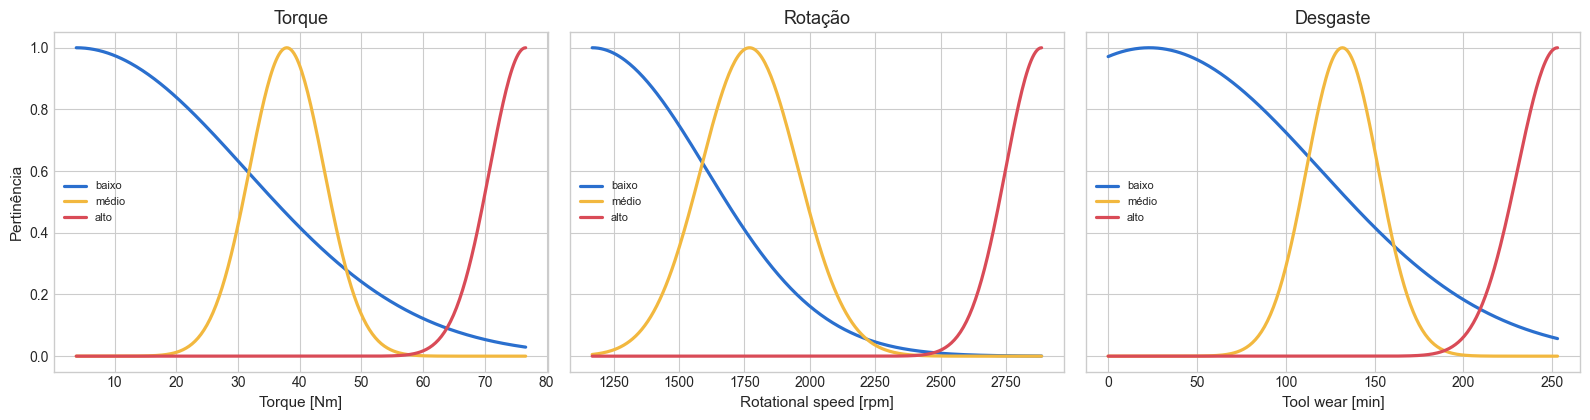

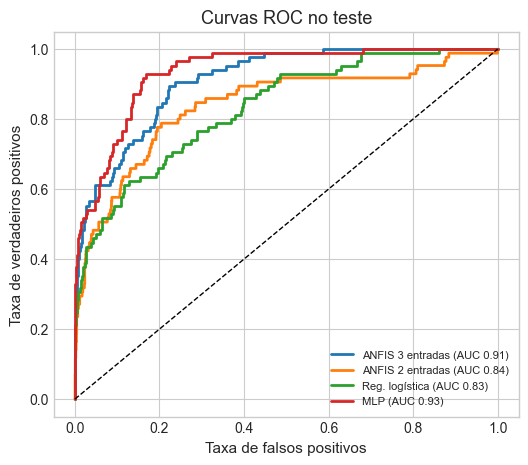

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
for j, ax in enumerate(axes):
    x_fis = lo[j] + grade * (hi[j] - lo[j])
    for i, nome in enumerate(TERMOS_PM):
        ax.plot(x_fis, pertinencia_gaussiana(grade, ct_[j], st_[j])[:, i], lw=2.3, color=CORES[i], label=nome)
    ax.set(title=NOMES_PM[j].capitalize(), xlabel=COLS[j])
    ax.legend(fontsize=8)
axes[0].set_ylabel("Pertinência")
plt.tight_layout()
plt.show()

from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(6, 5))
for nome, s in [("ANFIS 3 entradas", pm3.predict(Xn_te)), ("ANFIS 2 entradas", pm2.predict(Xn_te[:, sel2])),
                ("Reg. logística", logit.predict_proba(Xn_te)[:, 1]), ("MLP", mlp_pm.predict_proba(Xn_te)[:, 1])]:
    fpr, tpr, _ = roc_curve(f_te, s)
    ax.plot(fpr, tpr, lw=2, label=f"{nome} (AUC {roc_auc_score(f_te, s):.2f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set(xlabel="Taxa de falsos positivos", ylabel="Taxa de verdadeiros positivos", title="Curvas ROC no teste")
ax.legend(fontsize=8)
plt.show()

In [36]:
# Incerteza da comparação: bootstrap do conjunto de teste (só 85 falhas)
scores_te = {"ANFIS 3 entradas": pm3.predict(Xn_te), "Reg. logística": logit.predict_proba(Xn_te)[:, 1],
             "MLP": mlp_pm.predict_proba(Xn_te)[:, 1]}
rb = np.random.default_rng(0)
aucs = pd.DataFrame([
    {k: roc_auc_score(f_te[i], v[i]) for k, v in scores_te.items()}
    for i in (rb.integers(0, len(f_te), len(f_te)) for _ in range(500))
])
aucs["ANFIS − MLP"] = aucs["ANFIS 3 entradas"] - aucs["MLP"]
aucs["ANFIS − logística"] = aucs["ANFIS 3 entradas"] - aucs["Reg. logística"]
ic_boot = aucs.describe(percentiles=[0.025, 0.975]).loc[["mean", "2.5%", "97.5%"]].T
print("AUC-ROC no teste: média e intervalo de 95% em 500 reamostragens")
ic_boot.round(3)

AUC-ROC no teste: média e intervalo de 95% em 500 reamostragens


,mean,2.5%,97.5%
ANFIS 3 entradas,0.911,0.883,0.937
Reg. logística,0.833,0.791,0.876
MLP,0.935,0.913,0.956
ANFIS − MLP,-0.024,-0.044,-0.006
ANFIS − logística,0.077,0.048,0.113


**Análise.** (Teste com 2 500 registros, dos quais só **85 falhas**.)

| modelo | AUC-ROC | AP | precisão | recall | F1 |
|---|---|---|---|---|---|
| ANFIS 3 entradas (27 regras) | 0,911 | 0,470 | 0,50 | 0,45 | 0,47 |
| ANFIS 2 entradas (torque e desgaste) | 0,839 | 0,325 | 0,38 | 0,29 | 0,33 |
| Regressão logística | 0,832 | 0,381 | 0,54 | 0,31 | 0,39 |
| MLP (12 tanh) | 0,935 | 0,542 | 0,71 | 0,42 | 0,53 |

(AP de um classificador aleatório: 0,034. O limiar de decisão foi escolhido no treino.)

*Desempenho.* O ANFIS é **muito melhor que o acaso e que a regressão logística**, e um pouco pior que a
MLP. O bootstrap do teste indica que as duas diferenças são reais: ANFIS − logística = +0,077 (IC 95%:
+0,048 a +0,113) e ANFIS − MLP = −0,024 (IC 95%: −0,044 a −0,006). A logística falha porque o risco é
**não linear** e concentrado nos extremos. Incluir a rotação melhora muito o ANFIS (AUC 0,84 → 0,91), o que
combina com o modo de falha por potência (torque × rotação).

*O que foi aprendido.* Nas três variáveis, os termos "baixo" e "alto" ficam **nos extremos dos dados, ou perto deles**
(centros em 3,8 e 76,6 Nm; 1168 e 2886 rpm; ≈ 23 e 253 min de desgaste), e "alto" é bem estreito
(figura). O modelo reservou o termo "alto" para as caudas, onde estão as falhas. As regras de maior
risco fazem sentido físico:

- *torque baixo, rotação baixa, desgaste alto* → 100% (dominante em 64 amostras de treino, com 32
  falhas), coerente com a falha por desgaste da ferramenta;
- *torque alto, rotação baixa, desgaste baixo* → 97,6% (48 amostras, 38 falhas), coerente com
  sobrecarga.

*Cuidados.* Várias regras de "100%" são dominantes em 0 a 4 amostras: risco 100% com quase nenhum
respaldo, o problema de **cobertura** da seção 12. Como só há 85 falhas no teste, os intervalos são
largos. O alvo é 0/100 tratado como regressão, e o limiar, o número de termos (3) e o de iterações
(60) foram escolhas fixas, não ajustadas em validação. O modelo é um ponto de partida auditável, não
um preditor pronto para operar.

---
## Síntese

| # | Exercício | Resultado principal |
|---|---|---|
| 1 | Ruído | O erro vs. processo real cresce de 0,32 para 1,82 quando σ vai de 1 a 10, mas o principal efeito é a **instabilidade** dos centros (desvio de até 8 pontos) |
| 2 | Complexidade | 3 termos por entrada é o melhor compromisso (teste 2,73; erro vs. real 0,46); 4 termos ajustam ruído e pioram a interpretação |
| 3 | Operador E | O mínimo é pior em tudo (RMSE vs. real 1,19 contra 0,49) e gera superfície com quinas; prefira o produto para aprender |
| 4 | Poda | Nenhuma regra fica abaixo de 2%; com 4–6% a poda só é aceitável **com reajuste** (6 regras: 2,95 contra 2,73) |
| 5 | Primeira ordem | Melhora o treino e piora o teste (2,81 contra 2,73); coeficientes locais perdem sentido físico |
| 6 | Restrições | Sem limites o erro não melhora e os termos perdem o significado (0/10 partições ordenadas) |
| 7 | Robótica | 27 regras ficam bem atrás da MLP (8,4 contra 5,2); com 64 regras empatam; o modelo passa na auditoria de cenários |
| 8 | Manutenção preditiva | AUC 0,91: acima da logística (0,83), abaixo da MLP (0,94); regras interpretáveis, mas algumas com pouco respaldo |

**Lições que atravessam os exercícios**

1. **O RMSE de teste esconde diferenças.** Na base simulada quase todas as variantes ficam em
   2,7–2,9, perto do piso do ruído (2,5). As diferenças aparecem no erro contra o processo real,
   na estabilidade das pertinências e na interpretabilidade.
2. **Interpretabilidade é uma decisão de engenharia, não um efeito automático.** Limites nos centros
   preservam a ordem dos termos, mas não a coerência das regras (consequentes fora de ordem
   mesmo no modelo restrito).
3. **Regras crescem como m^d.** A grade completa já exigiu 64 regras para igualar a MLP com 3 sensores.
4. **Baixo erro não basta.** Em todos os casos foi preciso olhar as regras, as ativações e o respaldo
   nos dados para saber se o modelo faz sentido.